In [1]:
import pandas as pd

# Load cleaned dataset
file_path = r"D:\PatrolQ project\PatrolIQ_cleaned.csv"

df = pd.read_csv(file_path)

print("Cleaned dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Cleaned dataset loaded successfully!
Rows: 500000
Columns: 22


In [34]:
# ==========================================
# EDA 1 - DATASET OVERVIEW & DATA QUALITY
# ==========================================

print("=" * 60)
print("EDA 1 - DATASET OVERVIEW & DATA QUALITY")
print("=" * 60)

# 1. Number of records and columns
print("\n1. DATASET SHAPE")
print("Number of Records:", df.shape[0])
print("Number of Columns:", df.shape[1])

# 2. Date range
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("\n2. DATE RANGE")
print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

# 3. Data types
print("\n3. DATA TYPES")
print(df.dtypes)

# 4. Missing values
print("\n4. MISSING VALUES")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

# 5. Duplicate records
print("\n5. DUPLICATE RECORDS")
print("Number of Duplicate Rows:", df.duplicated().sum())

# 6. Statistical summary
print("\n6. STATISTICAL SUMMARY")
display(df.describe(include="all"))

EDA 1 - DATASET OVERVIEW & DATA QUALITY

1. DATASET SHAPE
Number of Records: 500000
Number of Columns: 26

2. DATE RANGE
Start Date: 2024-07-18 23:05:00
End Date: 2026-08-19 00:00:00

3. DATA TYPES
id                               int64
case_number                     object
date                    datetime64[ns]
block                           object
iucr                            object
primary_type                    object
description                     object
location_description            object
arrest                            bool
domestic                          bool
beat                             int64
district                       float64
ward                           float64
community_area                 float64
fbi_code                        object
x_coordinate                   float64
y_coordinate                   float64
year                             int64
updated_on                      object
latitude                       float64
longitude             

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,y_coordinate,year,updated_on,latitude,longitude,location,hour,day_of_week,month,season
count,5.000000e+05,500000,500000,500000,500000,500000,500000,500000,500000,500000,...,4.979830e+05,500000.000000,500000,497983.000000,497983.000000,497983,500000.000000,500000,500000.000000,500000
unique,NaN,499949,NaN,29559,352,31,330,136,2,2,...,NaN,NaN,1051,NaN,NaN,189994,NaN,7,NaN,4
top,NaN,JK261757,NaN,001XX N STATE ST,0486,THEFT,SIMPLE,STREET,False,False,...,NaN,NaN,2026-03-14 15:41:39,NaN,NaN,"(41.754592961, -87.741528537)",NaN,Friday,NaN,Summer
freq,NaN,4,NaN,1131,39780,114439,62695,134465,422898,405298,...,NaN,NaN,227490,NaN,NaN,601,NaN,73906,NaN,149970
mean,1.388855e+07,NaN,2025-07-26 00:50:51.713640192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.887274e+06,2025.052342,NaN,41.846255,-87.667789,NaN,12.467990,NaN,6.673656,NaN
min,2.827200e+04,NaN,2024-07-18 23:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.813897e+06,2024.000000,NaN,41.644590,-87.934567,NaN,0.000000,NaN,1.000000,NaN
25%,1.372259e+07,NaN,2025-01-12 06:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.860396e+06,2025.000000,NaN,41.772367,-87.708947,NaN,8.000000,NaN,4.000000,NaN
50%,1.391411e+07,NaN,2025-07-22 04:41:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.893758e+06,2025.000000,NaN,41.864128,-87.660388,NaN,13.000000,NaN,7.000000,NaN
75%,1.410656e+07,NaN,2026-02-04 19:42:45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.910004e+06,2026.000000,NaN,41.908858,-87.626471,NaN,18.000000,NaN,9.000000,NaN
max,1.430544e+07,NaN,2026-08-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.951517e+06,2026.000000,NaN,42.022559,-87.524529,NaN,23.000000,NaN,12.000000,NaN


EDA 2 - CRIME TYPE DISTRIBUTION

Number of Unique Crime Types:
31

Crime Count by Type:
primary_type
THEFT                                114439
BATTERY                               90228
CRIMINAL DAMAGE                       55084
ASSAULT                               45168
MOTOR VEHICLE THEFT                   38402
OTHER OFFENSE                         34148
DECEPTIVE PRACTICE                    30563
BURGLARY                              22782
NARCOTICS                             14236
ROBBERY                               12918
WEAPONS VIOLATION                     11991
CRIMINAL TRESPASS                     11149
CRIMINAL SEXUAL ASSAULT                3477
OFFENSE INVOLVING CHILDREN             3203
SEX OFFENSE                            2757
PUBLIC PEACE VIOLATION                 2321
INTERFERENCE WITH PUBLIC OFFICER       1885
STALKING                               1240
HOMICIDE                                982
ARSON                                   813
CONCEALED CARRY LIC

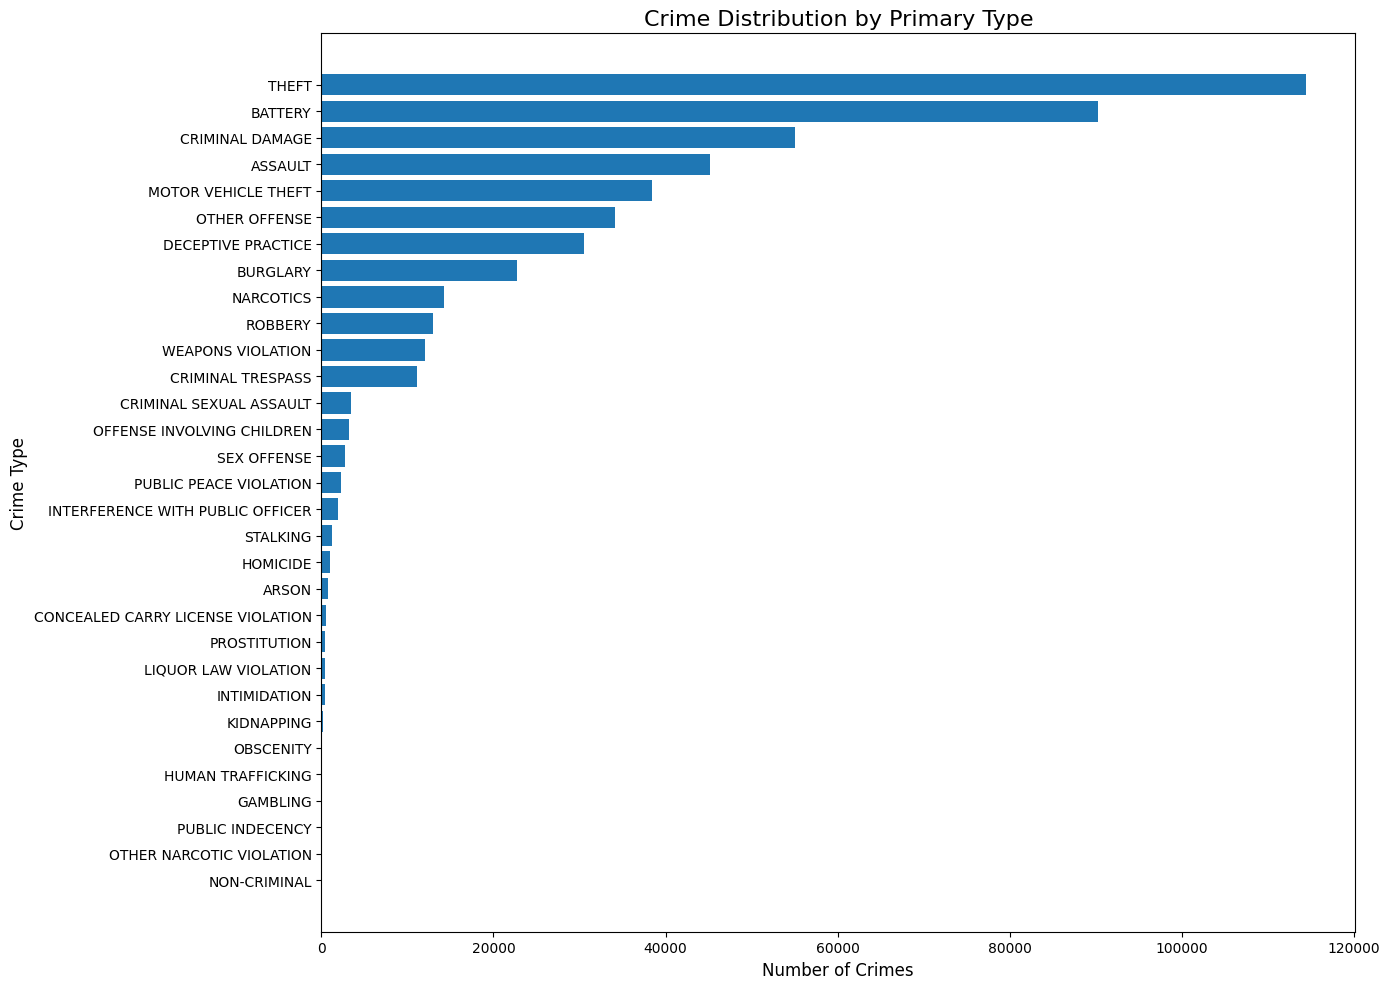

In [36]:
# ==========================================
# EDA 2 - CRIME TYPE DISTRIBUTION
# ==========================================

# Count crimes by primary type
crime_counts = df["primary_type"].value_counts()

# Print analysis
print("=" * 60)
print("EDA 2 - CRIME TYPE DISTRIBUTION")
print("=" * 60)

print("\nNumber of Unique Crime Types:")
print(df["primary_type"].nunique())

print("\nCrime Count by Type:")
print(crime_counts)

print("\nMost Common Crime Type:")
print(crime_counts.idxmax(), "-", crime_counts.max())

print("\nLeast Common Crime Type:")
print(crime_counts.idxmin(), "-", crime_counts.min())

# Visualization
plt.figure(figsize=(14, 10))

plt.barh(
    crime_counts.index[::-1],
    crime_counts.values[::-1]
)

plt.title("Crime Distribution by Primary Type", fontsize=16)
plt.xlabel("Number of Crimes", fontsize=12)
plt.ylabel("Crime Type", fontsize=12)

plt.tight_layout()
plt.show()

EDA 3 - GEOGRAPHIC CRIME PATTERNS

Total Records: 500000
Records with Valid Coordinates: 497983
Records with Missing Coordinates: 2017

Latitude Range:
Minimum: 41.644589713
Maximum: 42.022558955

Longitude Range:
Minimum: -87.934567226
Maximum: -87.524529378


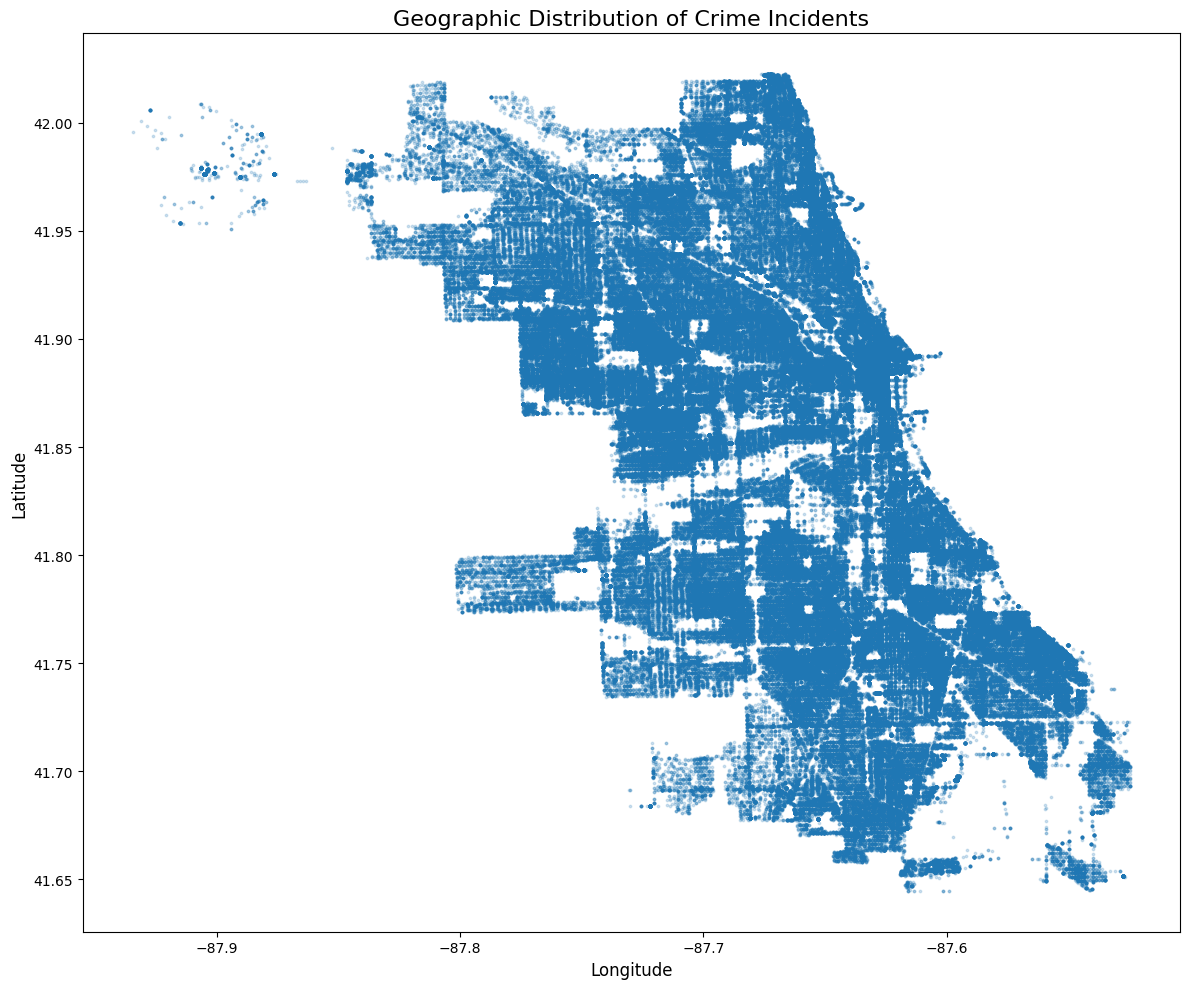

In [37]:
# ==========================================
# EDA 3 - GEOGRAPHIC CRIME PATTERNS
# ==========================================

# Select records with valid coordinates
geo_df = df.dropna(subset=["latitude", "longitude"])

# Print analysis
print("=" * 60)
print("EDA 3 - GEOGRAPHIC CRIME PATTERNS")
print("=" * 60)

print("\nTotal Records:", len(df))
print("Records with Valid Coordinates:", len(geo_df))
print("Records with Missing Coordinates:", len(df) - len(geo_df))

print("\nLatitude Range:")
print("Minimum:", geo_df["latitude"].min())
print("Maximum:", geo_df["latitude"].max())

print("\nLongitude Range:")
print("Minimum:", geo_df["longitude"].min())
print("Maximum:", geo_df["longitude"].max())

# Visualization
plt.figure(figsize=(12, 10))

plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"],
    alpha=0.2,
    s=3
)

plt.title("Geographic Distribution of Crime Incidents", fontsize=16)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

plt.tight_layout()
plt.show()

EDA 4 - HOURLY CRIME PATTERN

Crime Count by Hour:
hour
0     34224
1     16505
2     14664
3     13248
4     10795
5      9289
6     10096
7     12968
8     17235
9     20658
10    21558
11    22114
12    28404
13    22765
14    24210
15    27000
16    26703
17    26734
18    26603
19    25901
20    24498
21    22520
22    21591
23    19717
Name: count, dtype: int64

Peak Crime Hour:
0 :00 - 34224 crimes

Lowest Crime Hour:
5 :00 - 9289 crimes


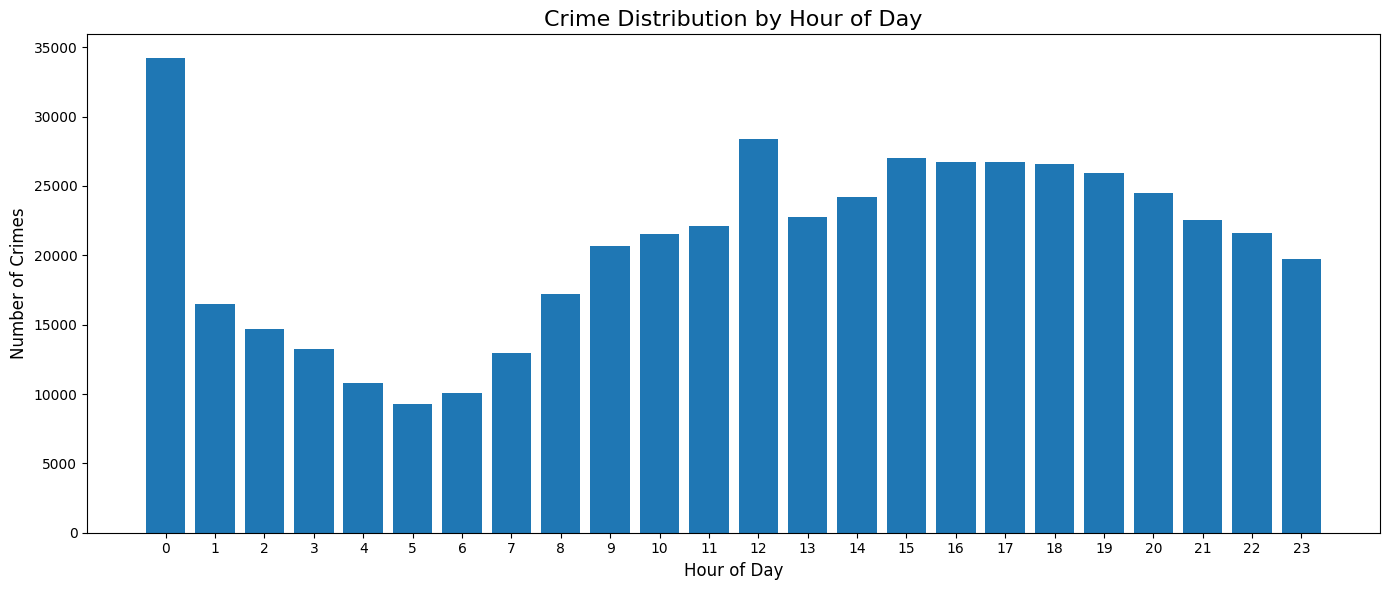

In [38]:
# ==========================================
# EDA 4 - HOURLY CRIME PATTERN
# ==========================================

# Extract hour from date
df["hour"] = df["date"].dt.hour

# Count crimes by hour
hourly_counts = df["hour"].value_counts().sort_index()

# Print analysis
print("=" * 60)
print("EDA 4 - HOURLY CRIME PATTERN")
print("=" * 60)

print("\nCrime Count by Hour:")
print(hourly_counts)

print("\nPeak Crime Hour:")
print(hourly_counts.idxmax(), ":00 -", hourly_counts.max(), "crimes")

print("\nLowest Crime Hour:")
print(hourly_counts.idxmin(), ":00 -", hourly_counts.min(), "crimes")

# Visualization
plt.figure(figsize=(14, 6))

plt.bar(
    hourly_counts.index,
    hourly_counts.values
)

plt.title("Crime Distribution by Hour of Day", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.xticks(range(24))

plt.tight_layout()
plt.show()

EDA 5 - DAILY CRIME PATTERN

Crime Count by Day:
day_of_week
Monday       71661
Tuesday      70191
Wednesday    69945
Thursday     69442
Friday       73906
Saturday     73315
Sunday       71540
Name: count, dtype: int64

Highest Crime Day:
Friday - 73906 crimes

Lowest Crime Day:
Thursday - 69442 crimes


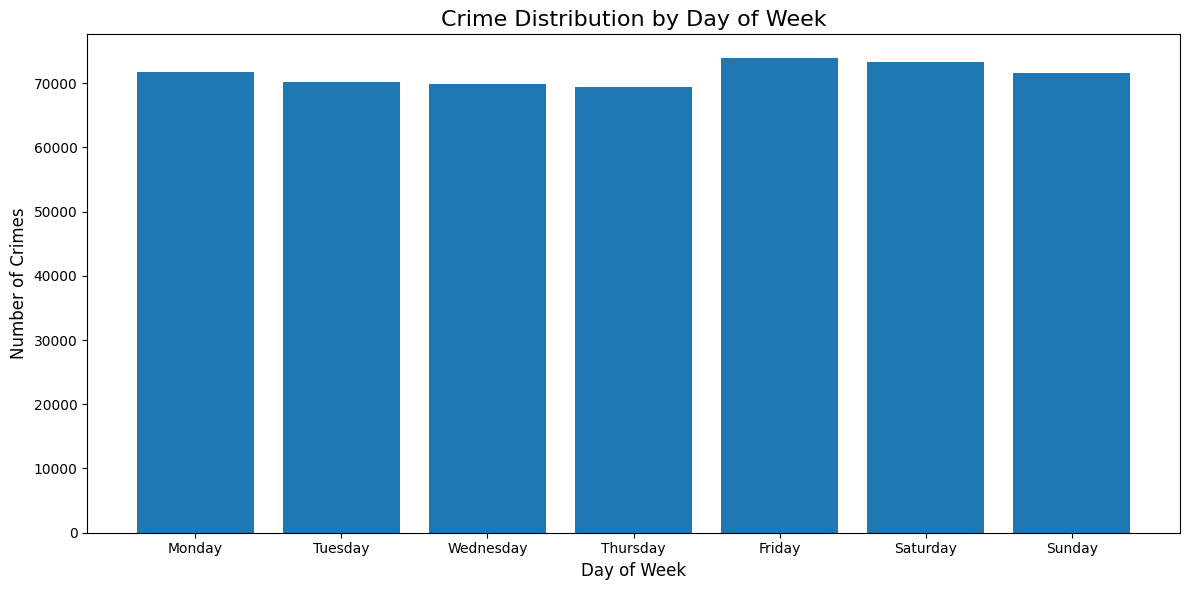

In [39]:
# ==========================================
# EDA 5 - DAILY CRIME PATTERN
# ==========================================

# Extract day of week
df["day_of_week"] = df["date"].dt.day_name()

# Define correct day order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Count crimes by day and arrange correctly
daily_counts = (
    df["day_of_week"]
    .value_counts()
    .reindex(day_order)
)

# Print analysis
print("=" * 60)
print("EDA 5 - DAILY CRIME PATTERN")
print("=" * 60)

print("\nCrime Count by Day:")
print(daily_counts)

print("\nHighest Crime Day:")
print(daily_counts.idxmax(), "-", daily_counts.max(), "crimes")

print("\nLowest Crime Day:")
print(daily_counts.idxmin(), "-", daily_counts.min(), "crimes")

# Visualization
plt.figure(figsize=(12, 6))

plt.bar(
    daily_counts.index,
    daily_counts.values
)

plt.title("Crime Distribution by Day of Week", fontsize=16)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

EDA 6 - MONTHLY CRIME PATTERN

Crime Count by Month:
month
1     35490
2     33063
3     38883
4     38760
5     41588
6     41057
7     53677
8     55236
9     43368
10    43518
11    38198
12    37162
Name: count, dtype: int64

Highest Crime Month:
8 - 55236 crimes

Lowest Crime Month:
2 - 33063 crimes


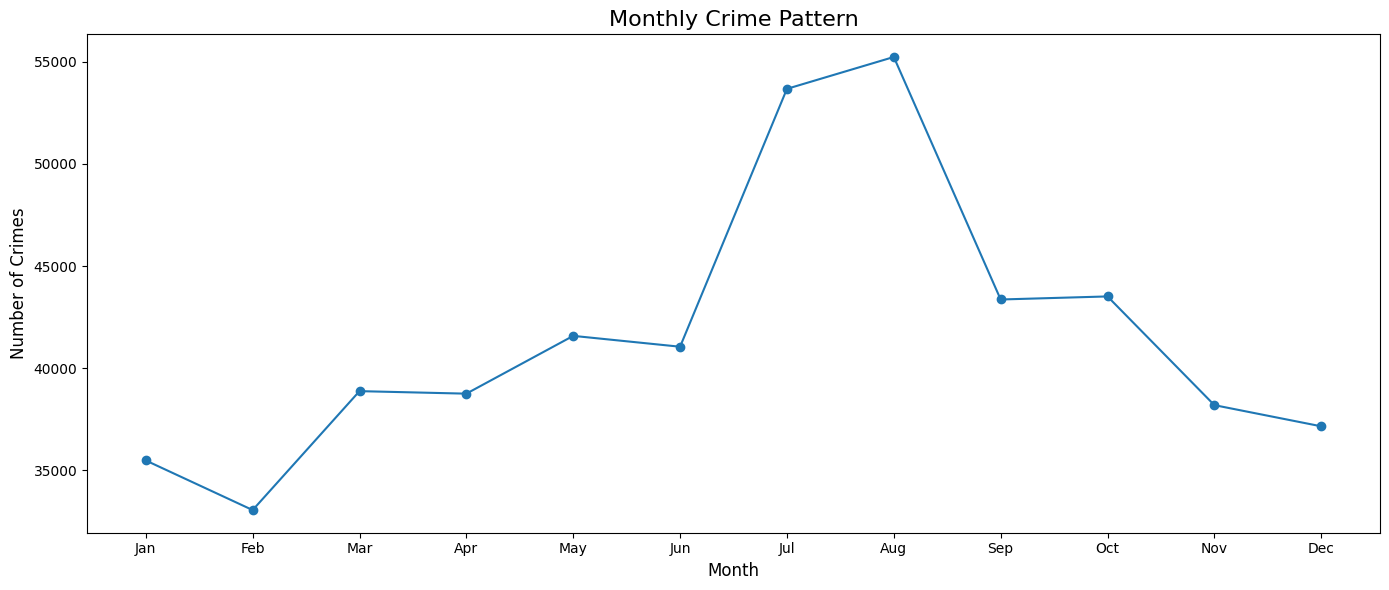

In [40]:
# ==========================================
# EDA 6 - MONTHLY CRIME PATTERN
# ==========================================

# Extract month from date
df["month"] = df["date"].dt.month

# Count crimes by month
monthly_counts = df["month"].value_counts().sort_index()

# Month names for visualization
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Print analysis
print("=" * 60)
print("EDA 6 - MONTHLY CRIME PATTERN")
print("=" * 60)

print("\nCrime Count by Month:")
print(monthly_counts)

print("\nHighest Crime Month:")
print(monthly_counts.idxmax(), "-", monthly_counts.max(), "crimes")

print("\nLowest Crime Month:")
print(monthly_counts.idxmin(), "-", monthly_counts.min(), "crimes")

# Visualization
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_counts.index,
    monthly_counts.values,
    marker="o"
)

plt.title("Monthly Crime Pattern", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.xticks(
    range(1, 13),
    month_names
)

plt.tight_layout()
plt.show()

EDA 7 - SEASONAL CRIME PATTERN

Crime Count by Season:
season
Winter    105715
Spring    119231
Summer    149970
Fall      125084
Name: count, dtype: int64

Highest Crime Season:
Summer - 149970 crimes

Lowest Crime Season:
Winter - 105715 crimes


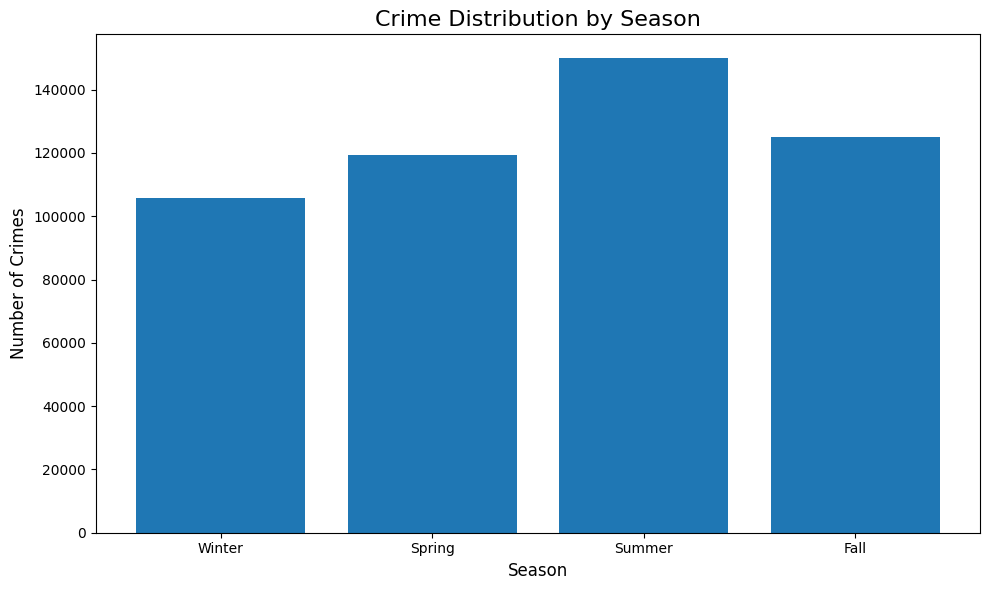

In [41]:
# ==========================================
# EDA 7 - SEASONAL CRIME PATTERN
# ==========================================

# Create season from month
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["date"].dt.month.apply(get_season)

# Define correct season order
season_order = ["Winter", "Spring", "Summer", "Fall"]

# Count crimes by season
season_counts = (
    df["season"]
    .value_counts()
    .reindex(season_order)
)

# Print analysis
print("=" * 60)
print("EDA 7 - SEASONAL CRIME PATTERN")
print("=" * 60)

print("\nCrime Count by Season:")
print(season_counts)

print("\nHighest Crime Season:")
print(season_counts.idxmax(), "-", season_counts.max(), "crimes")

print("\nLowest Crime Season:")
print(season_counts.idxmin(), "-", season_counts.min(), "crimes")

# Visualization
plt.figure(figsize=(10, 6))

plt.bar(
    season_counts.index,
    season_counts.values
)

plt.title("Crime Distribution by Season", fontsize=16)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.tight_layout()
plt.show()

EDA 8 - ARREST RATE ANALYSIS

Arrest Count:
arrest
False    422898
True      77102
Name: count, dtype: int64

Arrest Percentage:
arrest
False    84.58
True     15.42
Name: proportion, dtype: float64

Arrest Rate:
Arrested: 15.42 %
Not Arrested: 84.58 %


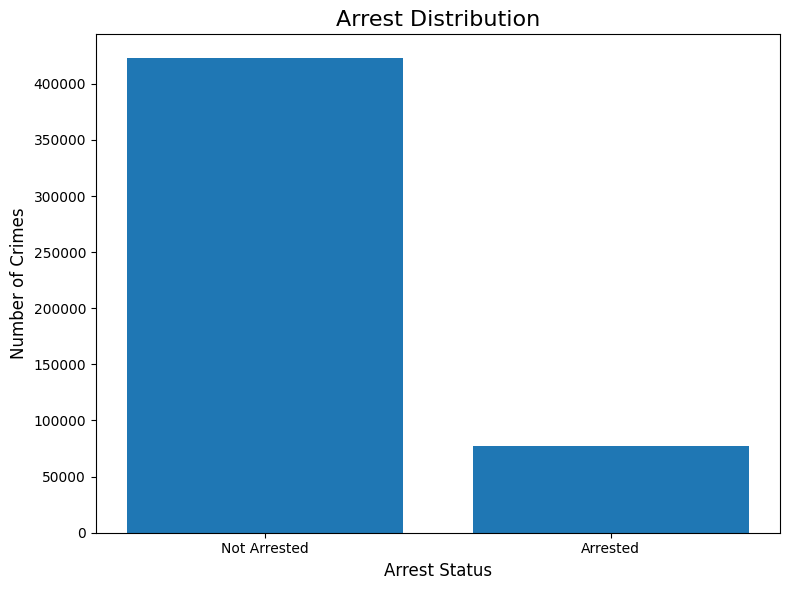

In [42]:
# ==========================================
# EDA 8 - ARREST RATE ANALYSIS
# ==========================================

# Count arrests
arrest_counts = df["arrest"].value_counts()

# Calculate percentages
arrest_percentages = df["arrest"].value_counts(normalize=True) * 100

print("=" * 60)
print("EDA 8 - ARREST RATE ANALYSIS")
print("=" * 60)

print("\nArrest Count:")
print(arrest_counts)

print("\nArrest Percentage:")
print(arrest_percentages.round(2))

# Highest category
print("\nArrest Rate:")
print(
    "Arrested:", 
    round(arrest_percentages.get(True, 0), 2), "%"
)

print(
    "Not Arrested:", 
    round(arrest_percentages.get(False, 0), 2), "%"
)

# Visualization
plt.figure(figsize=(8, 6))

plt.bar(
    ["Not Arrested", "Arrested"],
    [
        arrest_counts.get(False, 0),
        arrest_counts.get(True, 0)
    ]
)

plt.title("Arrest Distribution", fontsize=16)
plt.xlabel("Arrest Status", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.tight_layout()
plt.show()

EDA 9 - DOMESTIC INCIDENT ANALYSIS

Domestic Incident Count:
domestic
False    405298
True      94702
Name: count, dtype: int64

Domestic Incident Percentage:
domestic
False    81.06
True     18.94
Name: proportion, dtype: float64

Domestic Incident Rate:
Domestic: 18.94 %
Non-Domestic: 81.06 %


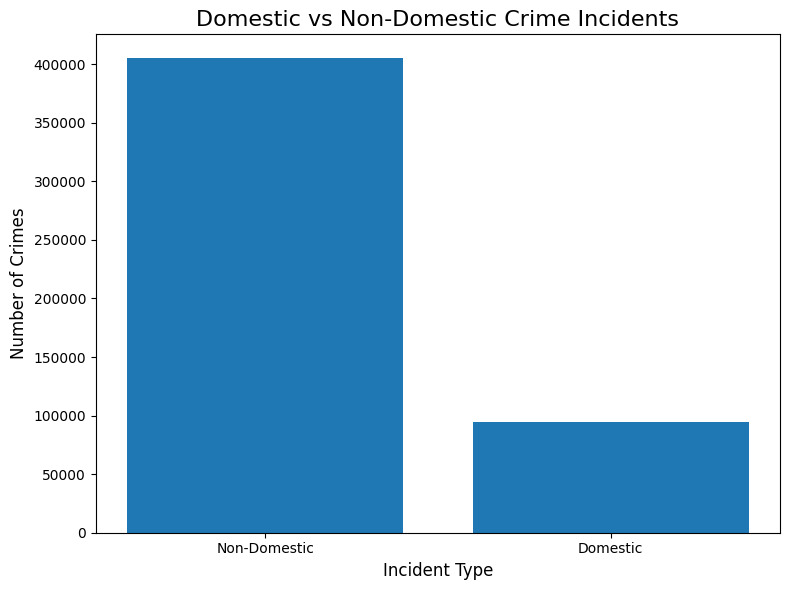

In [43]:
# ==========================================
# EDA 9 - DOMESTIC INCIDENT ANALYSIS
# ==========================================

# Count domestic incidents
domestic_counts = df["domestic"].value_counts()

# Calculate percentages
domestic_percentages = df["domestic"].value_counts(normalize=True) * 100

print("=" * 60)
print("EDA 9 - DOMESTIC INCIDENT ANALYSIS")
print("=" * 60)

print("\nDomestic Incident Count:")
print(domestic_counts)

print("\nDomestic Incident Percentage:")
print(domestic_percentages.round(2))

print("\nDomestic Incident Rate:")
print(
    "Domestic:", 
    round(domestic_percentages.get(True, 0), 2), "%"
)

print(
    "Non-Domestic:", 
    round(domestic_percentages.get(False, 0), 2), "%"
)

# Visualization
plt.figure(figsize=(8, 6))

plt.bar(
    ["Non-Domestic", "Domestic"],
    [
        domestic_counts.get(False, 0),
        domestic_counts.get(True, 0)
    ]
)

plt.title("Domestic vs Non-Domestic Crime Incidents", fontsize=16)
plt.xlabel("Incident Type", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.tight_layout()
plt.show()

EDA 10 - ARREST vs DOMESTIC CORRELATION

Arrest vs Domestic Count:
arrest     False  True 
domestic               
False     343320  61978
True       79578  15124

Arrest Percentage by Domestic Status:
arrest    False  True 
domestic              
False     84.71  15.29
True      84.03  15.97


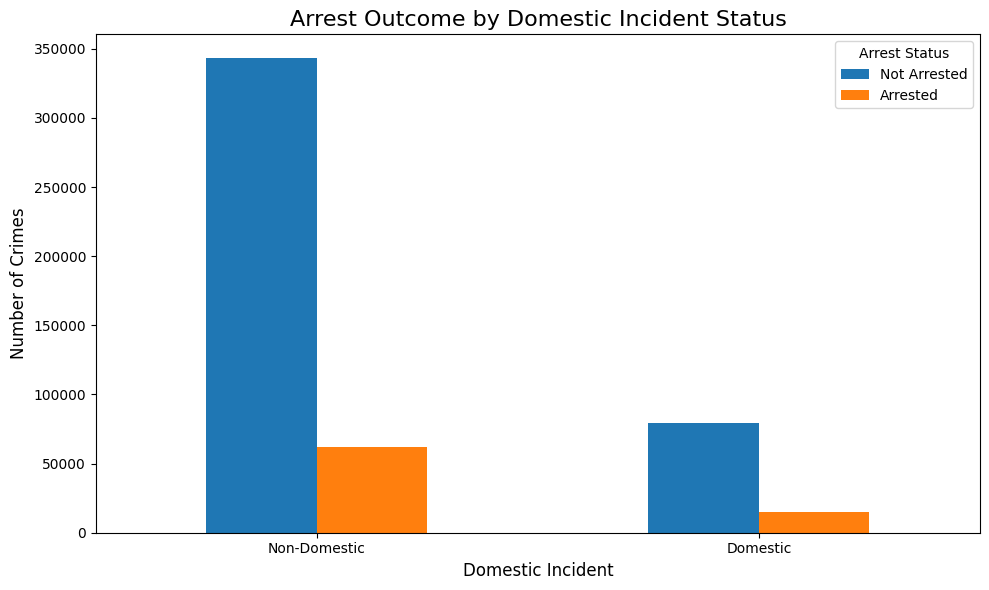

In [44]:
# ==========================================
# EDA 10 - ARREST vs DOMESTIC CORRELATION
# ==========================================

# Create cross-tabulation
arrest_domestic = pd.crosstab(
    df["domestic"],
    df["arrest"]
)

print("=" * 60)
print("EDA 10 - ARREST vs DOMESTIC CORRELATION")
print("=" * 60)

print("\nArrest vs Domestic Count:")
print(arrest_domestic)

# Calculate percentages within each domestic category
arrest_domestic_percentage = pd.crosstab(
    df["domestic"],
    df["arrest"],
    normalize="index"
) * 100

print("\nArrest Percentage by Domestic Status:")
print(arrest_domestic_percentage.round(2))

# Visualization
arrest_domestic.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Arrest Outcome by Domestic Incident Status", fontsize=16)
plt.xlabel("Domestic Incident", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.xticks(
    [0, 1],
    ["Non-Domestic", "Domestic"],
    rotation=0
)

plt.legend(
    ["Not Arrested", "Arrested"],
    title="Arrest Status"
)

plt.tight_layout()
plt.show()

EDA 11 - DISTRICT-WISE CRIME DISTRIBUTION

Crime Count by District:
district
1.0     28554
2.0     27083
3.0     26762
4.0     27327
5.0     19580
6.0     28329
7.0     21170
8.0     32135
9.0     22538
10.0    19888
11.0    27012
12.0    32154
14.0    18015
15.0    16821
16.0    16927
17.0    15046
18.0    27108
19.0    26736
20.0    10621
22.0    15535
24.0    15713
25.0    24927
Name: count, dtype: int64

Highest Crime District:
12.0 - 32154 crimes

Lowest Crime District:
20.0 - 10621 crimes


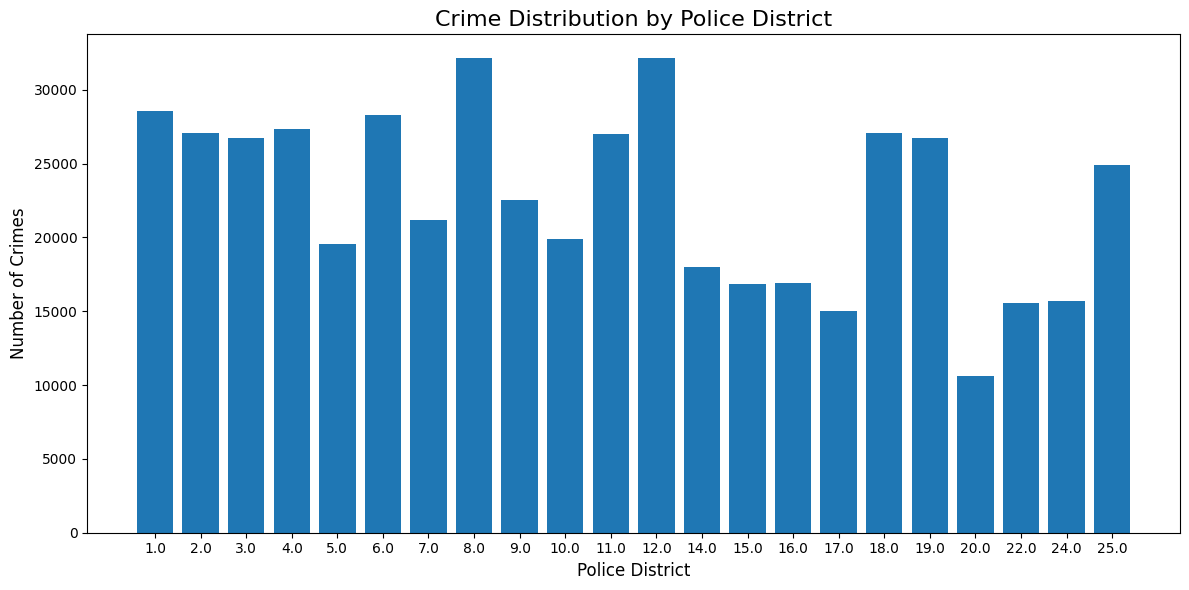

In [45]:
# ==========================================
# EDA 11 - DISTRICT-WISE CRIME DISTRIBUTION
# ==========================================

# Count crimes by district
district_counts = df["district"].value_counts().sort_index()

print("=" * 60)
print("EDA 11 - DISTRICT-WISE CRIME DISTRIBUTION")
print("=" * 60)

print("\nCrime Count by District:")
print(district_counts)

print("\nHighest Crime District:")
print(
    district_counts.idxmax(),
    "-",
    district_counts.max(),
    "crimes"
)

print("\nLowest Crime District:")
print(
    district_counts.idxmin(),
    "-",
    district_counts.min(),
    "crimes"
)

# Visualization
plt.figure(figsize=(12, 6))

plt.bar(
    district_counts.index.astype(str),
    district_counts.values
)

plt.title("Crime Distribution by Police District", fontsize=16)
plt.xlabel("Police District", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.tight_layout()
plt.show()

EDA 12 - COMMUNITY AREA CRIME DISTRIBUTION

Crime Count by Community Area:
community_area
1.0     7618
2.0     6889
3.0     8712
4.0     3976
5.0     2678
        ... 
73.0    5663
74.0    1075
75.0    3862
76.0    3322
77.0    6359
Name: count, Length: 77, dtype: int64

Number of Community Areas Represented:
77

Highest Crime Community Area:
25.0 - 25190 crimes

Lowest Crime Community Area:
9.0 - 508 crimes


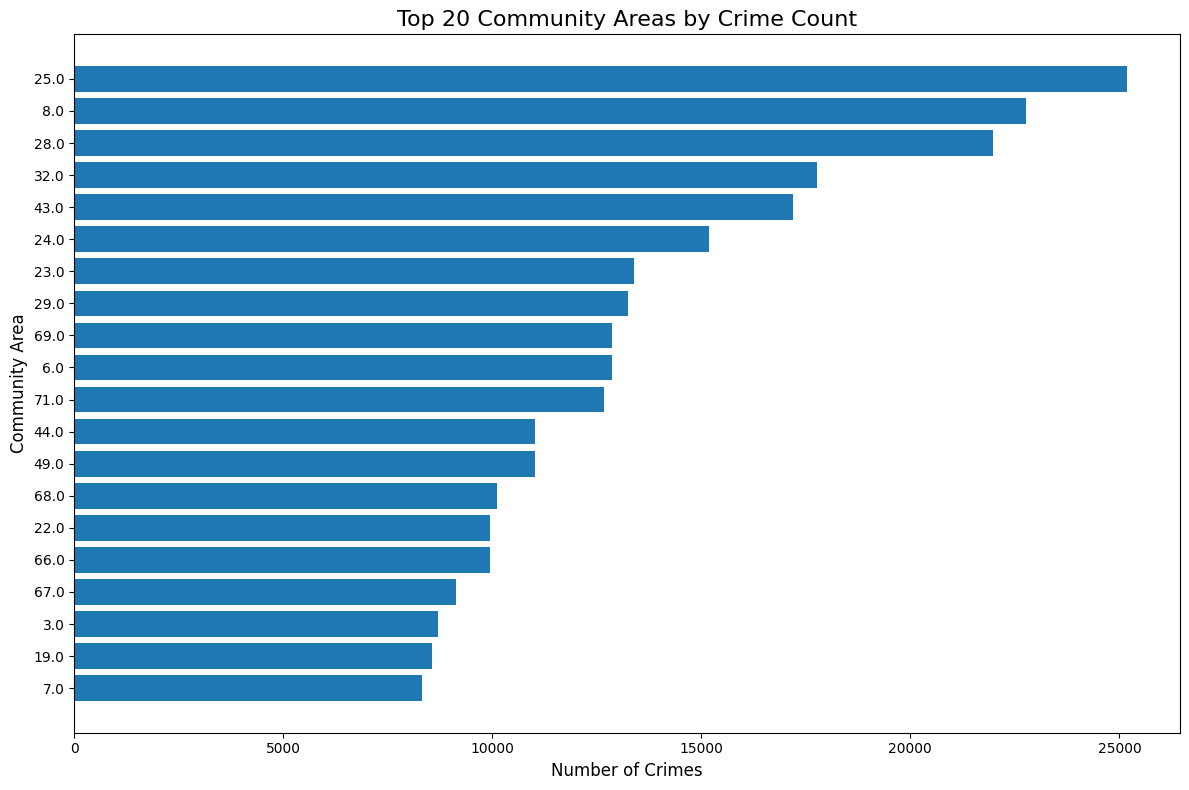

In [46]:
# ==========================================
# EDA 12 - COMMUNITY AREA CRIME DISTRIBUTION
# ==========================================

# Count crimes by community area
community_counts = df["community_area"].value_counts().sort_index()

print("=" * 60)
print("EDA 12 - COMMUNITY AREA CRIME DISTRIBUTION")
print("=" * 60)

print("\nCrime Count by Community Area:")
print(community_counts)

print("\nNumber of Community Areas Represented:")
print(df["community_area"].nunique())

print("\nHighest Crime Community Area:")
print(
    community_counts.idxmax(),
    "-",
    community_counts.max(),
    "crimes"
)

print("\nLowest Crime Community Area:")
print(
    community_counts.idxmin(),
    "-",
    community_counts.min(),
    "crimes"
)

# Visualization - Top 20 community areas
top_20_communities = df["community_area"].value_counts().head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    top_20_communities.index.astype(str)[::-1],
    top_20_communities.values[::-1]
)

plt.title("Top 20 Community Areas by Crime Count", fontsize=16)
plt.xlabel("Number of Crimes", fontsize=12)
plt.ylabel("Community Area", fontsize=12)

plt.tight_layout()
plt.show()

EDA 13 - CRIME TYPE vs ARREST RATE

Arrest Rate by Crime Type (%):
primary_type
CONCEALED CARRY LICENSE VIOLATION    95.82
NARCOTICS                            95.31
GAMBLING                             94.44
LIQUOR LAW VIOLATION                 94.38
PUBLIC INDECENCY                     93.55
PROSTITUTION                         93.45
INTERFERENCE WITH PUBLIC OFFICER     91.14
WEAPONS VIOLATION                    73.71
PUBLIC PEACE VIOLATION               51.70
NON-CRIMINAL                         50.00
OBSCENITY                            47.46
OTHER NARCOTIC VIOLATION             47.06
HOMICIDE                             33.60
CRIMINAL TRESPASS                    31.58
OTHER OFFENSE                        19.07
BATTERY                              18.69
ASSAULT                              12.52
ARSON                                 9.35
ROBBERY                               9.10
KIDNAPPING                            9.09
SEX OFFENSE                           8.89
THEFT            

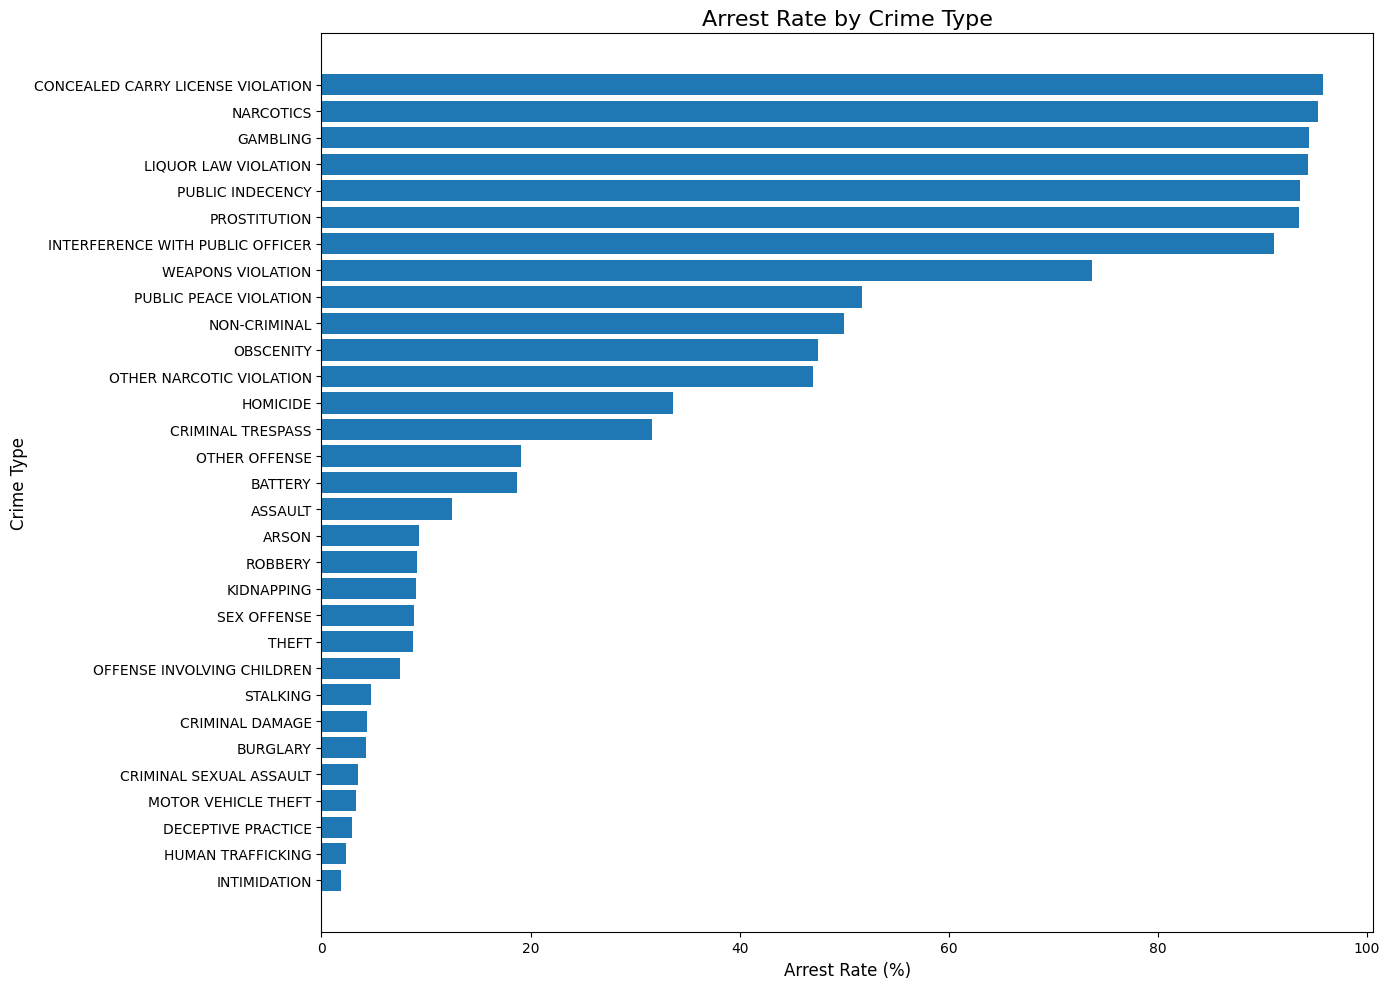

In [47]:
# ==========================================
# EDA 13 - CRIME TYPE vs ARREST RATE
# ==========================================

# Calculate arrest rate for each crime type
crime_arrest_rate = (
    df.groupby("primary_type")["arrest"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("=" * 60)
print("EDA 13 - CRIME TYPE vs ARREST RATE")
print("=" * 60)

print("\nArrest Rate by Crime Type (%):")
print(crime_arrest_rate.round(2))

print("\nHighest Arrest Rate:")
print(
    crime_arrest_rate.index[0],
    "-",
    round(crime_arrest_rate.iloc[0], 2),
    "%"
)

print("\nLowest Arrest Rate:")
print(
    crime_arrest_rate.index[-1],
    "-",
    round(crime_arrest_rate.iloc[-1], 2),
    "%"
)

# Visualization
plt.figure(figsize=(14, 10))

plt.barh(
    crime_arrest_rate.index[::-1],
    crime_arrest_rate.values[::-1]
)

plt.title("Arrest Rate by Crime Type", fontsize=16)
plt.xlabel("Arrest Rate (%)", fontsize=12)
plt.ylabel("Crime Type", fontsize=12)

plt.tight_layout()
plt.show()

EDA 14 - CRIME TYPE vs DOMESTIC INCIDENTS

Domestic Incident Rate by Crime Type (%):
primary_type
OFFENSE INVOLVING CHILDREN           75.40
BATTERY                              53.23
STALKING                             46.53
KIDNAPPING                           43.54
OTHER OFFENSE                        36.25
ASSAULT                              28.28
OBSCENITY                            25.42
SEX OFFENSE                          22.74
CRIMINAL SEXUAL ASSAULT              20.45
INTIMIDATION                         16.27
CRIMINAL DAMAGE                      13.89
HUMAN TRAFFICKING                     9.52
ARSON                                 9.35
HOMICIDE                              9.27
CRIMINAL TRESPASS                     7.51
THEFT                                 5.09
ROBBERY                               3.34
PUBLIC PEACE VIOLATION                3.27
BURGLARY                              2.81
MOTOR VEHICLE THEFT                   1.88
INTERFERENCE WITH PUBLIC OFFICER      1.75

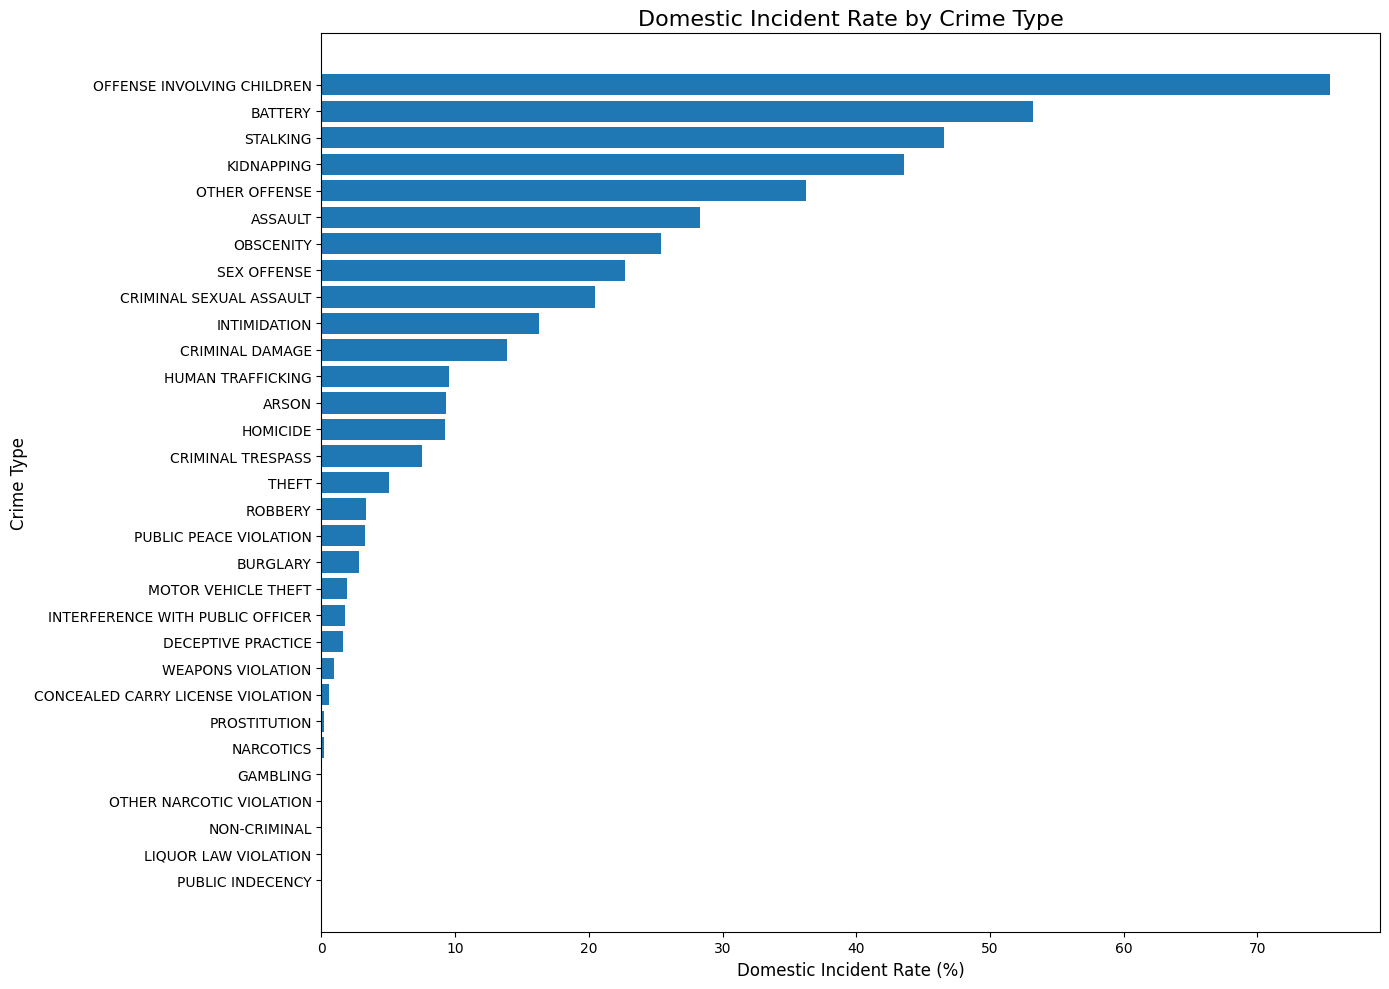

In [48]:
# ==========================================
# EDA 14 - CRIME TYPE vs DOMESTIC INCIDENTS
# ==========================================

# Calculate domestic incident rate by crime type
crime_domestic_rate = (
    df.groupby("primary_type")["domestic"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("=" * 60)
print("EDA 14 - CRIME TYPE vs DOMESTIC INCIDENTS")
print("=" * 60)

print("\nDomestic Incident Rate by Crime Type (%):")
print(crime_domestic_rate.round(2))

print("\nHighest Domestic Incident Rate:")
print(
    crime_domestic_rate.index[0],
    "-",
    round(crime_domestic_rate.iloc[0], 2),
    "%"
)

print("\nLowest Domestic Incident Rate:")
print(
    crime_domestic_rate.index[-1],
    "-",
    round(crime_domestic_rate.iloc[-1], 2),
    "%"
)

# Visualization
plt.figure(figsize=(14, 10))

plt.barh(
    crime_domestic_rate.index[::-1],
    crime_domestic_rate.values[::-1]
)

plt.title("Domestic Incident Rate by Crime Type", fontsize=16)
plt.xlabel("Domestic Incident Rate (%)", fontsize=12)
plt.ylabel("Crime Type", fontsize=12)

plt.tight_layout()
plt.show()

EDA 15 - CRIME LOCATION DISTRIBUTION

Number of Unique Crime Locations:
136

Top 20 Crime Locations:
location_description
STREET                                    134465
APARTMENT                                  97408
RESIDENCE                                  59365
SIDEWALK                                   25673
SMALL RETAIL STORE                         18463
PARKING LOT / GARAGE (NON RESIDENTIAL)     17610
DEPARTMENT STORE                           11446
RESTAURANT                                 11321
ALLEY                                      10912
OTHER (SPECIFY)                             8660
VEHICLE NON-COMMERCIAL                      7843
COMMERCIAL / BUSINESS OFFICE                7212
GAS STATION                                 6076
RESIDENCE - PORCH / HALLWAY                 5989
GROCERY FOOD STORE                          5331
RESIDENCE - YARD (FRONT / BACK)             5099
RESIDENCE - GARAGE                          4356
PARK PROPERTY                               3

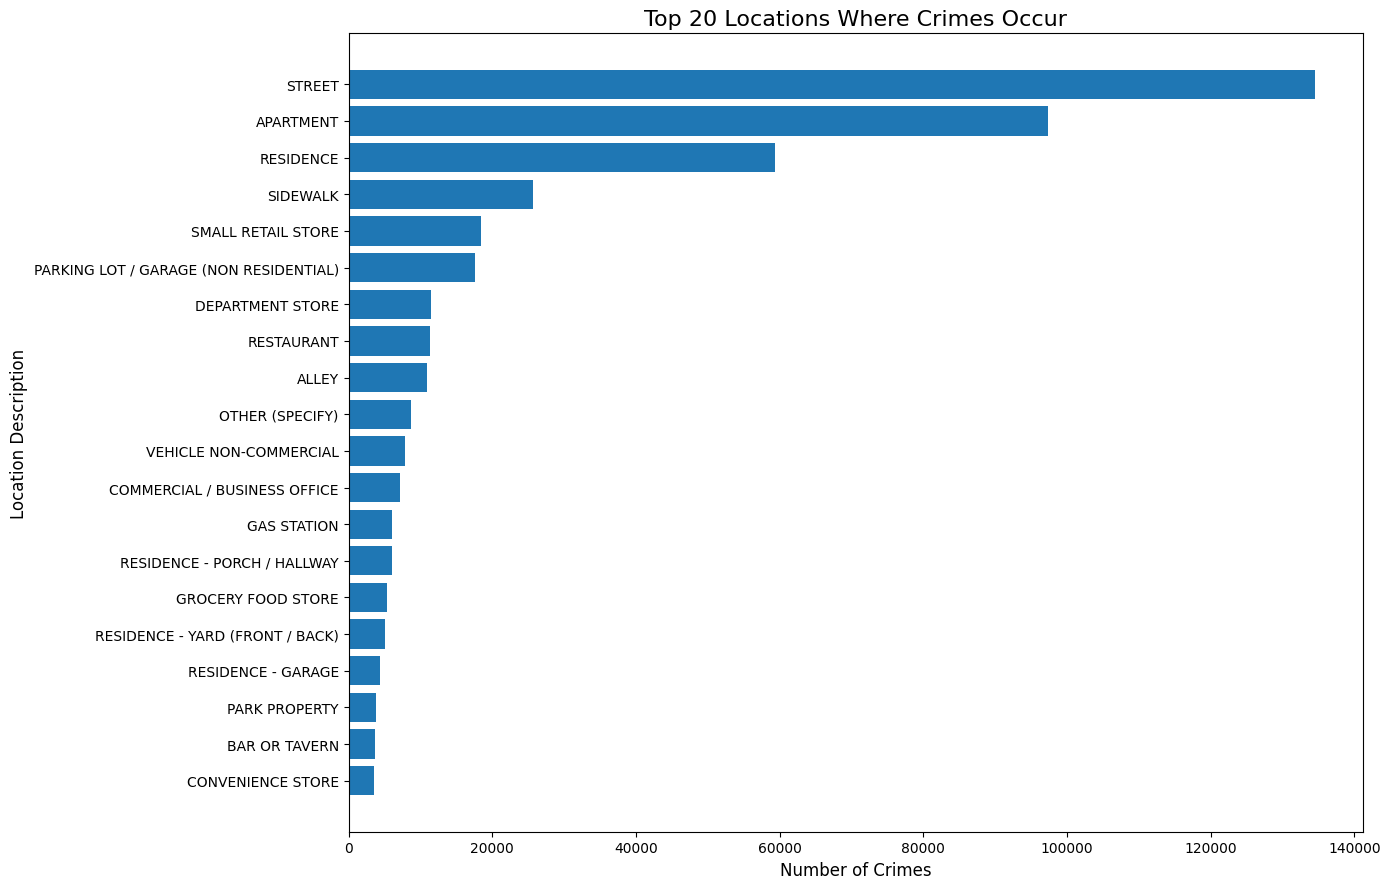

In [49]:
# ==========================================
# EDA 15 - CRIME LOCATION DISTRIBUTION
# ==========================================

# Count crimes by location
location_counts = df["location_description"].value_counts()

print("=" * 60)
print("EDA 15 - CRIME LOCATION DISTRIBUTION")
print("=" * 60)

print("\nNumber of Unique Crime Locations:")
print(df["location_description"].nunique())

print("\nTop 20 Crime Locations:")
print(location_counts.head(20))

print("\nMost Common Crime Location:")
print(
    location_counts.index[0],
    "-",
    location_counts.iloc[0],
    "crimes"
)

# Visualization - Top 20 locations
top_20_locations = location_counts.head(20)

plt.figure(figsize=(14, 9))

plt.barh(
    top_20_locations.index[::-1],
    top_20_locations.values[::-1]
)

plt.title("Top 20 Locations Where Crimes Occur", fontsize=16)
plt.xlabel("Number of Crimes", fontsize=12)
plt.ylabel("Location Description", fontsize=12)

plt.tight_layout()
plt.show()

EDA 16 - YEARLY CRIME TREND

Crime Count by Year:
year
2024    118082
2025    237665
2026    144253
Name: count, dtype: int64

Highest Crime Year:
2025 - 237665 crimes

Lowest Crime Year:
2024 - 118082 crimes


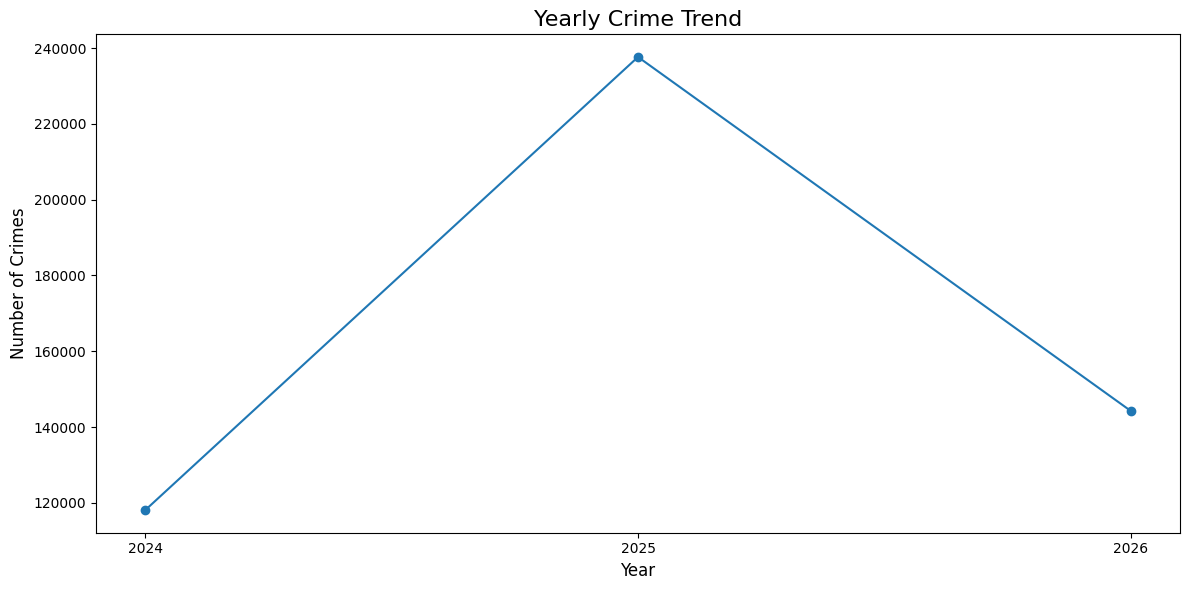

In [50]:
# ==========================================
# EDA 16 - YEARLY CRIME TREND
# ==========================================

# Count crimes by year
yearly_counts = df["year"].value_counts().sort_index()

print("=" * 60)
print("EDA 16 - YEARLY CRIME TREND")
print("=" * 60)

print("\nCrime Count by Year:")
print(yearly_counts)

print("\nHighest Crime Year:")
print(
    yearly_counts.idxmax(),
    "-",
    yearly_counts.max(),
    "crimes"
)

print("\nLowest Crime Year:")
print(
    yearly_counts.idxmin(),
    "-",
    yearly_counts.min(),
    "crimes"
)

# Visualization
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_counts.index,
    yearly_counts.values,
    marker="o"
)

plt.title("Yearly Crime Trend", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.xticks(yearly_counts.index)

plt.tight_layout()
plt.show()

EDA 17 - WEEKDAY vs WEEKEND CRIME

Crime Count:
is_weekend
False    355145
True     144855
Name: count, dtype: int64

Crime Percentage:
is_weekend
False    71.03
True     28.97
Name: proportion, dtype: float64

Weekday Crimes:
355145

Weekend Crimes:
144855


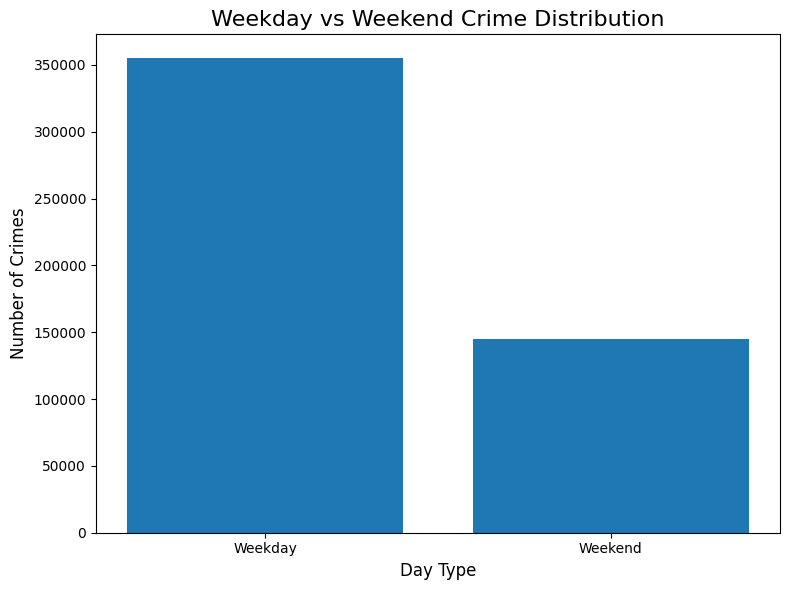

In [51]:
# ==========================================
# EDA 17 - WEEKDAY vs WEEKEND CRIME
# ==========================================

# Create weekend flag
df["is_weekend"] = df["date"].dt.dayofweek >= 5

# Count crimes
weekend_counts = df["is_weekend"].value_counts()

# Calculate percentages
weekend_percentages = df["is_weekend"].value_counts(normalize=True) * 100

print("=" * 60)
print("EDA 17 - WEEKDAY vs WEEKEND CRIME")
print("=" * 60)

print("\nCrime Count:")
print(weekend_counts)

print("\nCrime Percentage:")
print(weekend_percentages.round(2))

print("\nWeekday Crimes:")
print(weekend_counts.get(False, 0))

print("\nWeekend Crimes:")
print(weekend_counts.get(True, 0))

# Visualization
plt.figure(figsize=(8, 6))

plt.bar(
    ["Weekday", "Weekend"],
    [
        weekend_counts.get(False, 0),
        weekend_counts.get(True, 0)
    ]
)

plt.title("Weekday vs Weekend Crime Distribution", fontsize=16)
plt.xlabel("Day Type", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.tight_layout()
plt.show()

EDA 18 - CRIME TYPE BY YEAR

Crime Type Distribution by Year:
primary_type  ARSON  ASSAULT  BATTERY  BURGLARY  \
year                                              
2024            206    10551    20770      4311   
2025            374    21598    42618      9739   
2026            233    13019    26840      8732   

primary_type  CONCEALED CARRY LICENSE VIOLATION  CRIMINAL DAMAGE  \
year                                                               
2024                                         91            13033   
2025                                        277            26245   
2026                                        158            15806   

primary_type  CRIMINAL SEXUAL ASSAULT  CRIMINAL TRESPASS  DECEPTIVE PRACTICE  \
year                                                                           
2024                              756               2329                7174   
2025                             1680               5326               15250   
2026                 

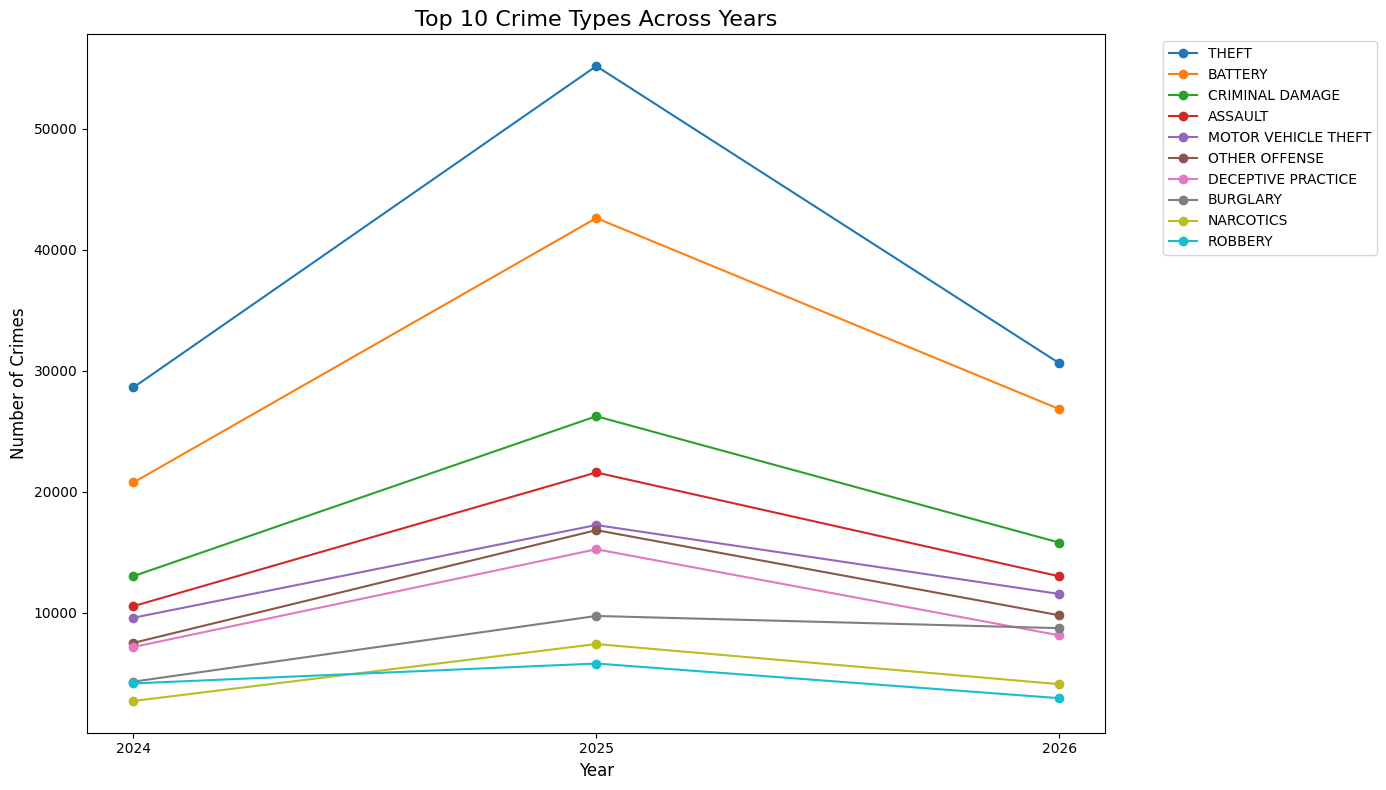

In [52]:
# ==========================================
# EDA 18 - CRIME TYPE BY YEAR
# ==========================================

# Create cross-tabulation
crime_year = pd.crosstab(
    df["year"],
    df["primary_type"]
)

print("=" * 60)
print("EDA 18 - CRIME TYPE BY YEAR")
print("=" * 60)

print("\nCrime Type Distribution by Year:")
print(crime_year)

# Find top 5 crime types for each year
print("\nTop 5 Crime Types by Year:")

for year in crime_year.index:
    top_5 = crime_year.loc[year].sort_values(ascending=False).head(5)
    
    print(f"\n{year}:")
    print(top_5)

# Visualization - Top 10 crime types overall by year
top_10_crimes = df["primary_type"].value_counts().head(10).index

crime_year_top10 = crime_year[top_10_crimes]

plt.figure(figsize=(14, 8))

for crime in crime_year_top10.columns:
    plt.plot(
        crime_year_top10.index,
        crime_year_top10[crime],
        marker="o",
        label=crime
    )

plt.title("Top 10 Crime Types Across Years", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.xticks(crime_year_top10.index)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

EDA 19 - HOURLY CRIME PATTERN: WEEKDAY vs WEEKEND

Crime Count by Hour and Day Type:
day_type  Weekday  Weekend
hour                      
0           23260    10964
1           10040     6465
2            8642     6022
3            7917     5331
4            6817     3978
5            6255     3034
6            7233     2863
7            9803     3165
8           13000     4235
9           15494     5164
10          15973     5585
11          16468     5646
12          20934     7470
13          16747     6018
14          17772     6438
15          20032     6968
16          19537     7166
17          19469     7265
18          19476     7127
19          18849     7052
20          17468     7030
21          15795     6725
22          14856     6735
23          13308     6409

Peak Weekday Crime Hour:
0 :00 - 23260 crimes

Peak Weekend Crime Hour:
0 :00 - 10964 crimes


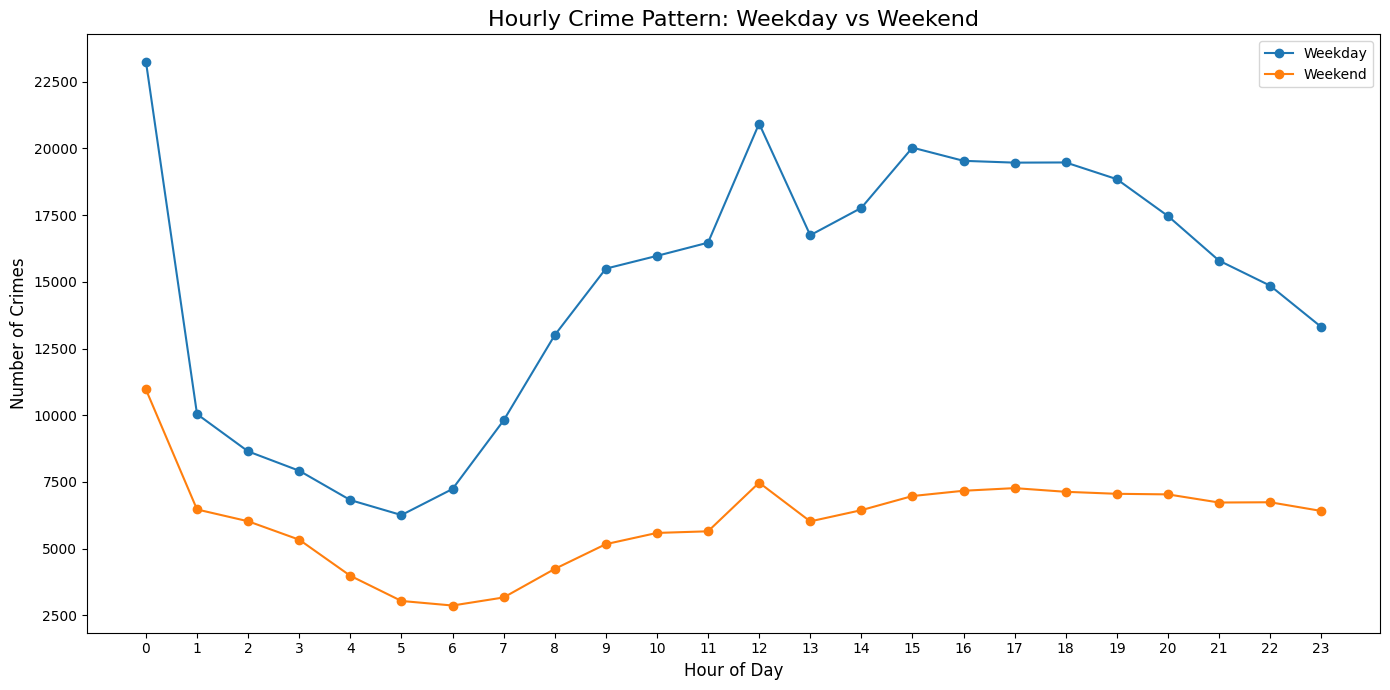

In [53]:
# ==========================================
# EDA 19 - HOURLY CRIME PATTERN
#            WEEKDAY vs WEEKEND
# ==========================================

# Create day type
df["day_type"] = df["date"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# Create hour
df["hour"] = df["date"].dt.hour

# Count crimes by hour and day type
hour_daytype = pd.crosstab(
    df["hour"],
    df["day_type"]
)

print("=" * 60)
print("EDA 19 - HOURLY CRIME PATTERN: WEEKDAY vs WEEKEND")
print("=" * 60)

print("\nCrime Count by Hour and Day Type:")
print(hour_daytype)

# Peak weekday hour
weekday_peak_hour = hour_daytype["Weekday"].idxmax()

# Peak weekend hour
weekend_peak_hour = hour_daytype["Weekend"].idxmax()

print("\nPeak Weekday Crime Hour:")
print(
    weekday_peak_hour,
    ":00 -",
    hour_daytype.loc[weekday_peak_hour, "Weekday"],
    "crimes"
)

print("\nPeak Weekend Crime Hour:")
print(
    weekend_peak_hour,
    ":00 -",
    hour_daytype.loc[weekend_peak_hour, "Weekend"],
    "crimes"
)

# Visualization
plt.figure(figsize=(14, 7))

plt.plot(
    hour_daytype.index,
    hour_daytype["Weekday"],
    marker="o",
    label="Weekday"
)

plt.plot(
    hour_daytype.index,
    hour_daytype["Weekend"],
    marker="o",
    label="Weekend"
)

plt.title(
    "Hourly Crime Pattern: Weekday vs Weekend",
    fontsize=16
)

plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.xticks(range(24))

plt.legend()

plt.tight_layout()
plt.show()

EDA 20 - CRIME TYPE BY LOCATION

Top 10 Locations:
['STREET', 'APARTMENT', 'RESIDENCE', 'SIDEWALK', 'SMALL RETAIL STORE', 'PARKING LOT / GARAGE (NON RESIDENTIAL)', 'DEPARTMENT STORE', 'RESTAURANT', 'ALLEY', 'OTHER (SPECIFY)']

Crime Distribution by Top Locations:
primary_type                            ARSON  ASSAULT  BATTERY  BURGLARY  \
location_description                                                        
ALLEY                                      87     1095     1633       235   
APARTMENT                                 135    11827    29560      4481   
DEPARTMENT STORE                            1      390      309        77   
OTHER (SPECIFY)                             6      606      856       310   
PARKING LOT / GARAGE (NON RESIDENTIAL)     29     1010     1597      1458   
RESIDENCE                                 114     5719    13443      2687   
RESTAURANT                                 13     1293     1812      1076   
SIDEWALK                                   

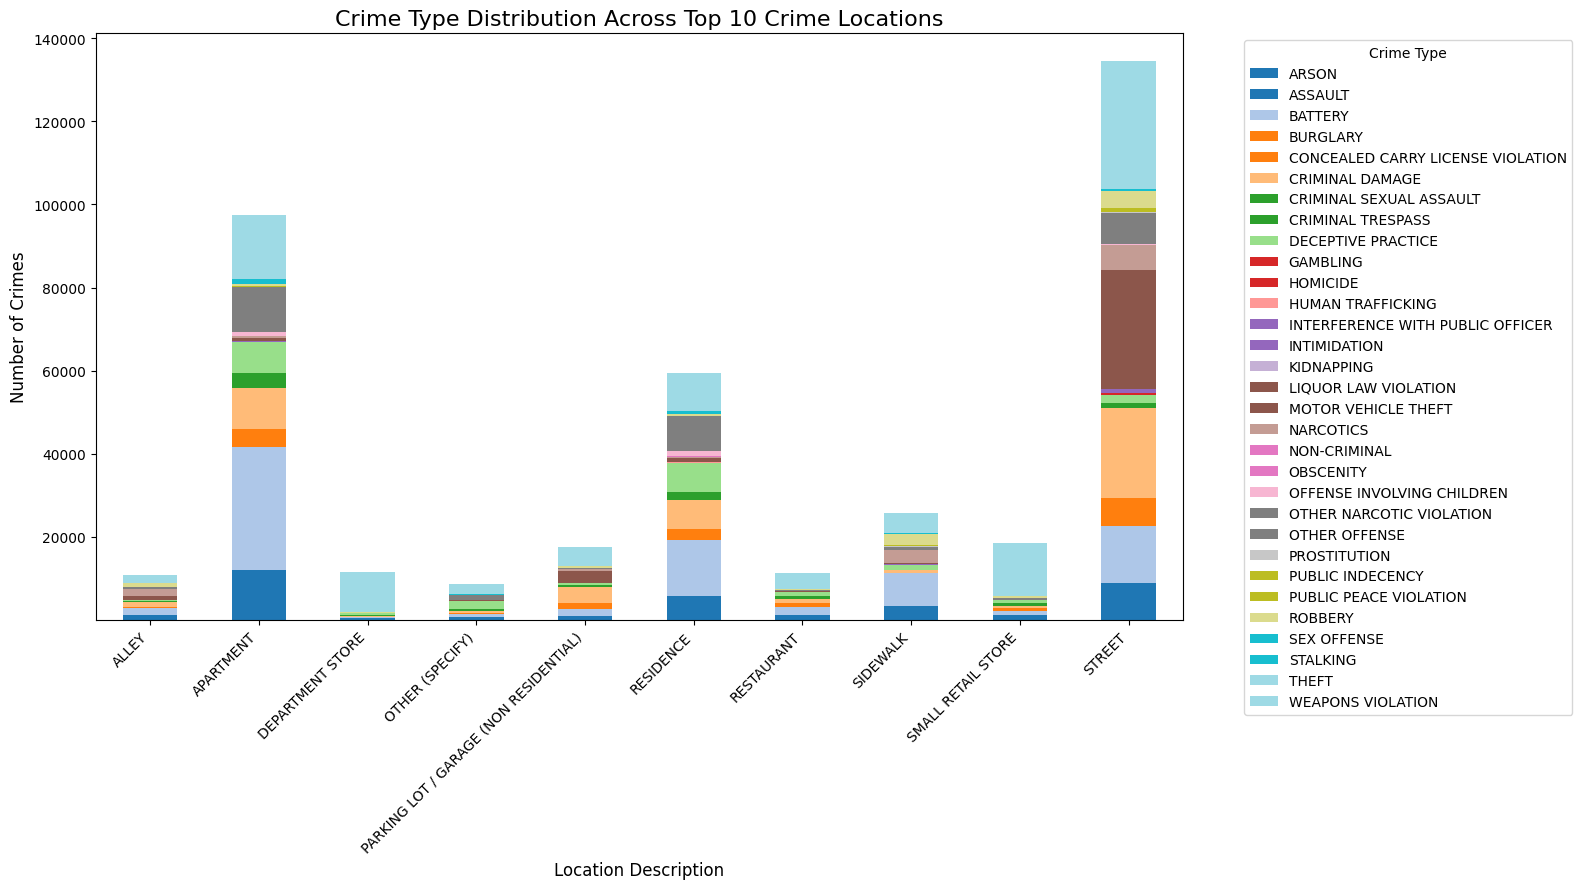

In [54]:
# ==========================================
# EDA 20 - CRIME TYPE BY LOCATION
# ==========================================

# Get top 10 locations
top_locations = (
    df["location_description"]
    .value_counts()
    .head(10)
    .index
)

# Filter dataset
location_crime = df[
    df["location_description"].isin(top_locations)
]

# Create cross-tabulation
location_crime_table = pd.crosstab(
    location_crime["location_description"],
    location_crime["primary_type"]
)

print("=" * 60)
print("EDA 20 - CRIME TYPE BY LOCATION")
print("=" * 60)

print("\nTop 10 Locations:")
print(top_locations.tolist())

print("\nCrime Distribution by Top Locations:")
print(location_crime_table)

# Find dominant crime type for each location
dominant_crime = location_crime_table.idxmax(axis=1)

print("\nDominant Crime Type by Location:")
print(dominant_crime)

# Visualization - stacked bar chart
location_crime_table.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 9),
    colormap="tab20"
)

plt.title(
    "Crime Type Distribution Across Top 10 Crime Locations",
    fontsize=16
)

plt.xlabel("Location Description", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Crime Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

EDA 21 - CRIME DISTRIBUTION BY DISTRICT

Crime Count by District:
district
1.0     28554
2.0     27083
3.0     26762
4.0     27327
5.0     19580
6.0     28329
7.0     21170
8.0     32135
9.0     22538
10.0    19888
11.0    27012
12.0    32154
14.0    18015
15.0    16821
16.0    16927
17.0    15046
18.0    27108
19.0    26736
20.0    10621
22.0    15535
24.0    15713
25.0    24927
Name: count, dtype: int64

Crime Percentage by District:
district
1.0     5.71
2.0     5.42
3.0     5.35
4.0     5.47
5.0     3.92
6.0     5.67
7.0     4.23
8.0     6.43
9.0     4.51
10.0    3.98
11.0    5.40
12.0    6.43
14.0    3.60
15.0    3.36
16.0    3.39
17.0    3.01
18.0    5.42
19.0    5.35
20.0    2.12
22.0    3.11
24.0    3.14
25.0    4.99
Name: proportion, dtype: float64

Highest Crime Share:
12.0 - 6.43 %

Lowest Crime Share:
20.0 - 2.12 %


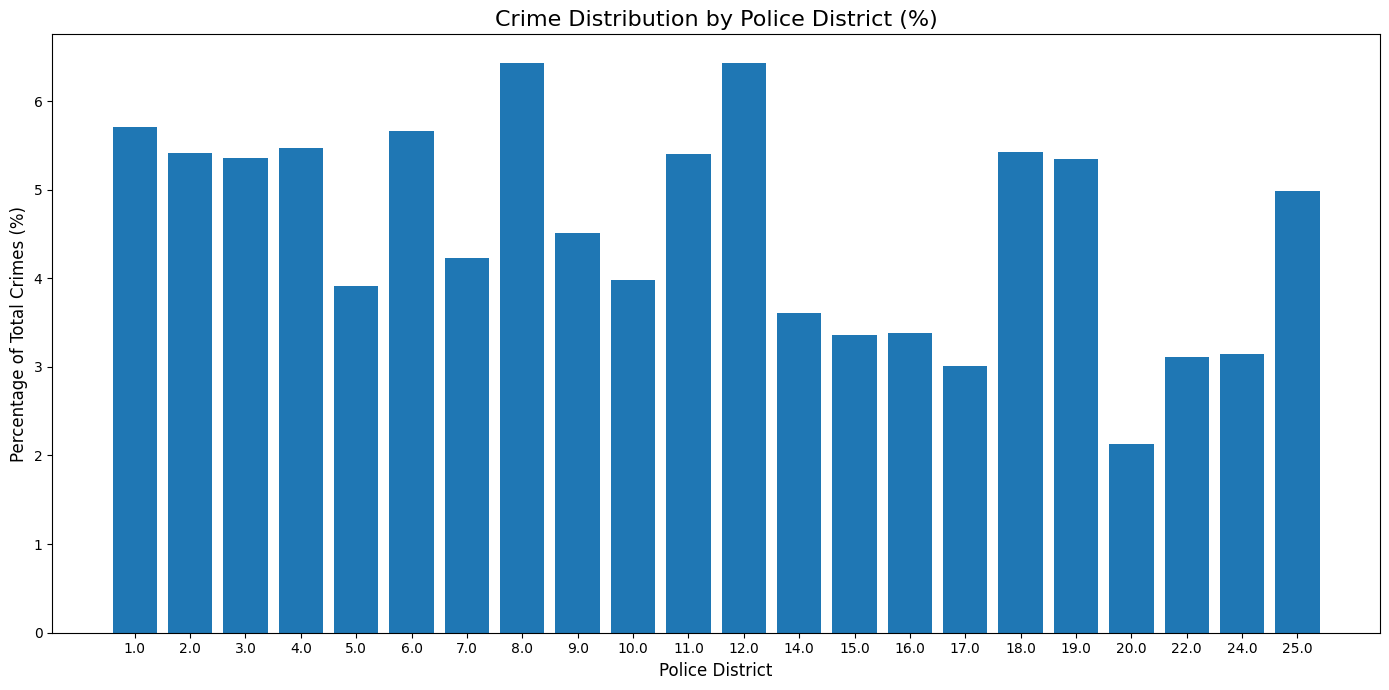

In [55]:
# ==========================================
# EDA 21 - CRIME DISTRIBUTION BY DISTRICT %
# ==========================================

# Crime count by district
district_counts = df["district"].value_counts().sort_index()

# Percentage distribution
district_percentage = (
    df["district"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

print("=" * 60)
print("EDA 21 - CRIME DISTRIBUTION BY DISTRICT")
print("=" * 60)

print("\nCrime Count by District:")
print(district_counts)

print("\nCrime Percentage by District:")
print(district_percentage.round(2))

print("\nHighest Crime Share:")
print(
    district_percentage.idxmax(),
    "-",
    round(district_percentage.max(), 2),
    "%"
)

print("\nLowest Crime Share:")
print(
    district_percentage.idxmin(),
    "-",
    round(district_percentage.min(), 2),
    "%"
)

# Visualization
plt.figure(figsize=(14, 7))

plt.bar(
    district_percentage.index.astype(str),
    district_percentage.values
)

plt.title(
    "Crime Distribution by Police District (%)",
    fontsize=16
)

plt.xlabel("Police District", fontsize=12)
plt.ylabel("Percentage of Total Crimes (%)", fontsize=12)

plt.tight_layout()
plt.show()

EDA 22 - CRIME SEVERITY ANALYSIS

Crime Count by Severity:
crime_severity_score
1         8
2    184393
3    143285
4    167604
5      4710
Name: count, dtype: int64

Crime Percentage by Severity:
crime_severity_score
1     0.00
2    36.88
3    28.66
4    33.52
5     0.94
Name: proportion, dtype: float64

Average Crime Severity Score:
2.99

Crime Types by Severity:
primary_type
CRIMINAL SEXUAL ASSAULT              5
HUMAN TRAFFICKING                    5
HOMICIDE                             5
KIDNAPPING                           5
BATTERY                              4
ASSAULT                              4
ARSON                                4
CONCEALED CARRY LICENSE VIOLATION    4
SEX OFFENSE                          4
WEAPONS VIOLATION                    4
OFFENSE INVOLVING CHILDREN           4
ROBBERY                              4
BURGLARY                             3
CRIMINAL DAMAGE                      3
CRIMINAL TRESPASS                    3
STALKING                          

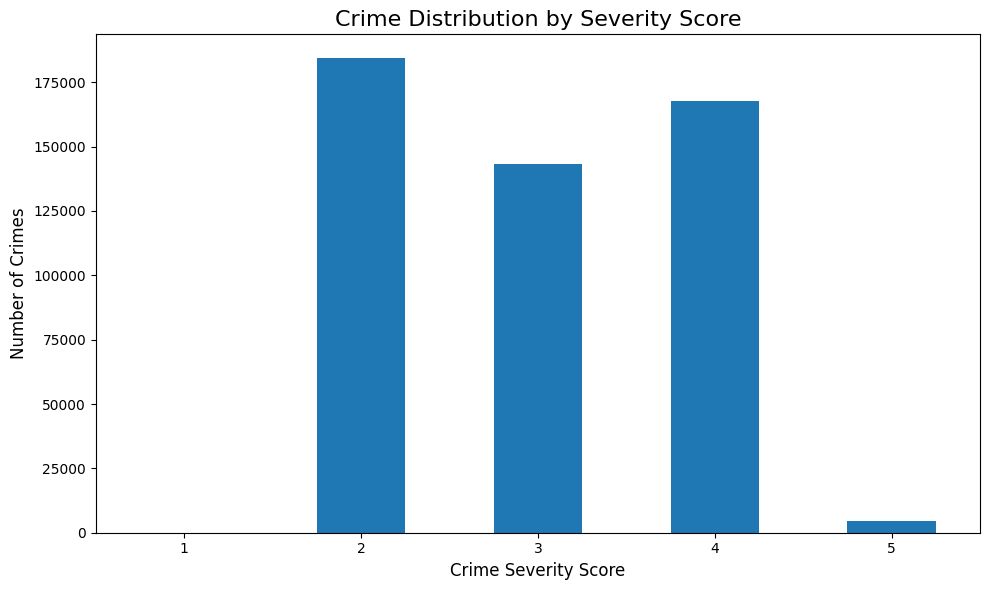

In [56]:
# ==========================================
# EDA 22 - CRIME SEVERITY ANALYSIS
# ==========================================

# Define severity scores
severity_map = {
    "HOMICIDE": 5,
    "CRIMINAL SEXUAL ASSAULT": 5,
    "KIDNAPPING": 5,
    "HUMAN TRAFFICKING": 5,
    "ROBBERY": 4,
    "WEAPONS VIOLATION": 4,
    "ARSON": 4,
    "ASSAULT": 4,
    "BATTERY": 4,
    "BURGLARY": 3,
    "MOTOR VEHICLE THEFT": 3,
    "CRIMINAL DAMAGE": 3,
    "CRIMINAL TRESPASS": 3,
    "STALKING": 3,
    "OFFENSE INVOLVING CHILDREN": 4,
    "SEX OFFENSE": 4,
    "INTIMIDATION": 3,
    "NARCOTICS": 3,
    "DECEPTIVE PRACTICE": 2,
    "THEFT": 2,
    "OTHER OFFENSE": 2,
    "PUBLIC PEACE VIOLATION": 2,
    "INTERFERENCE WITH PUBLIC OFFICER": 2,
    "LIQUOR LAW VIOLATION": 2,
    "PROSTITUTION": 2,
    "GAMBLING": 2,
    "OBSCENITY": 2,
    "PUBLIC INDECENCY": 2,
    "CONCEALED CARRY LICENSE VIOLATION": 4,
    "OTHER NARCOTIC VIOLATION": 3,
    "NON-CRIMINAL": 1
}

# Create severity score
df["crime_severity_score"] = (
    df["primary_type"]
    .map(severity_map)
    .fillna(1)
)

print("=" * 60)
print("EDA 22 - CRIME SEVERITY ANALYSIS")
print("=" * 60)

# Severity distribution
severity_counts = df["crime_severity_score"].value_counts().sort_index()

print("\nCrime Count by Severity:")
print(severity_counts)

# Percentage distribution
severity_percentage = (
    df["crime_severity_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("\nCrime Percentage by Severity:")
print(severity_percentage.round(2))

# Average severity
print("\nAverage Crime Severity Score:")
print(round(df["crime_severity_score"].mean(), 2))

# Highest severity crimes
high_severity = (
    df.groupby("primary_type")["crime_severity_score"]
    .first()
    .sort_values(ascending=False)
)

print("\nCrime Types by Severity:")
print(high_severity)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 6))

severity_counts.plot(
    kind="bar"
)

plt.title(
    "Crime Distribution by Severity Score",
    fontsize=16
)

plt.xlabel(
    "Crime Severity Score",
    fontsize=12
)

plt.ylabel(
    "Number of Crimes",
    fontsize=12
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

EDA 23 - CRIME SEVERITY BY DISTRICT

Average Crime Severity by District:
          mean  count
district             
15.0      3.20  16821
7.0       3.20  21170
11.0      3.19  27012
10.0      3.15  19888
3.0       3.15  26762
4.0       3.12  27327
6.0       3.11  28329
5.0       3.08  19580
9.0       3.06  22538
8.0       3.00  32135
25.0      2.99  24927
2.0       2.99  27083
22.0      2.98  15535
24.0      2.95  15713
12.0      2.90  32154
16.0      2.88  16927
20.0      2.87  10621
17.0      2.85  15046
14.0      2.79  18015
1.0       2.77  28554
19.0      2.72  26736
18.0      2.71  27108

Highest Average Severity District:
15.0 - 3.2

Lowest Average Severity District:
18.0 - 2.71


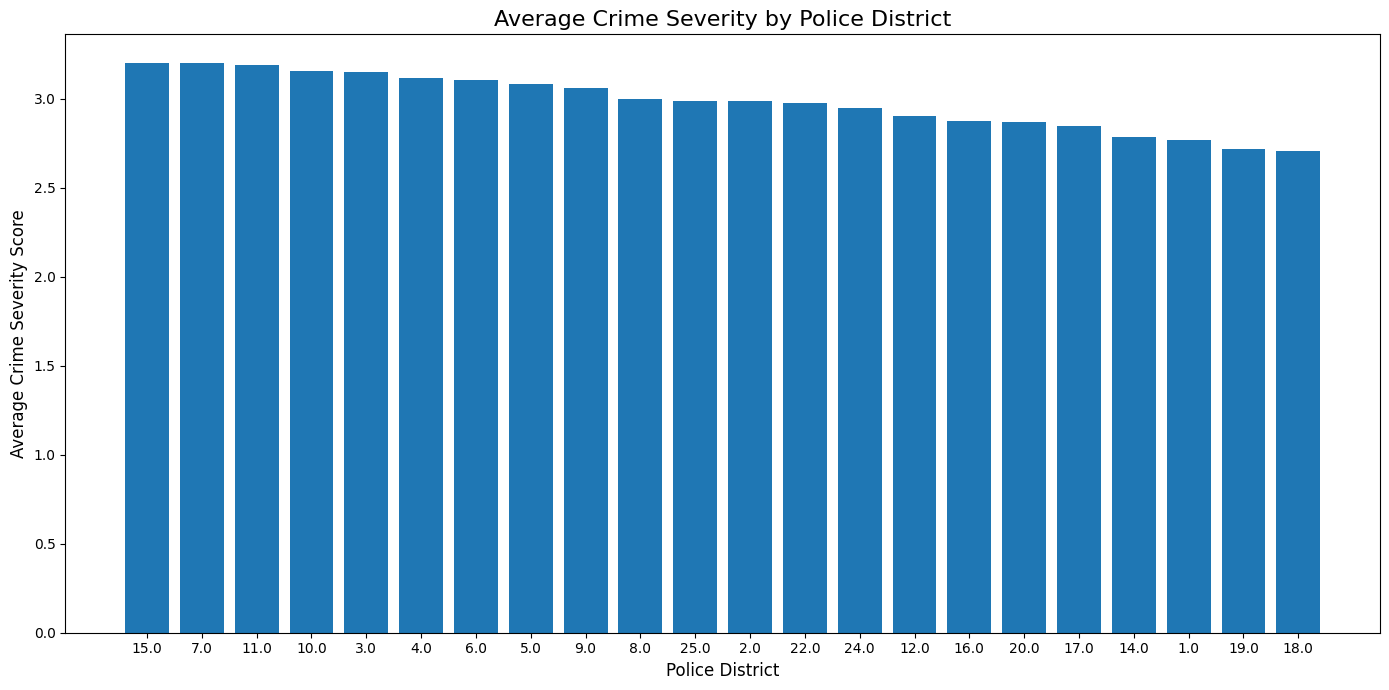

In [57]:
# ==========================================
# EDA 23 - CRIME SEVERITY BY DISTRICT
# ==========================================

district_severity = (
    df.groupby("district")["crime_severity_score"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

print("=" * 60)
print("EDA 23 - CRIME SEVERITY BY DISTRICT")
print("=" * 60)

print("\nAverage Crime Severity by District:")
print(district_severity.round(2))

print("\nHighest Average Severity District:")
print(
    district_severity.index[0],
    "-",
    round(district_severity.iloc[0]["mean"], 2)
)

print("\nLowest Average Severity District:")
print(
    district_severity.index[-1],
    "-",
    round(district_severity.iloc[-1]["mean"], 2)
)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(14, 7))

plt.bar(
    district_severity.index.astype(str),
    district_severity["mean"]
)

plt.title(
    "Average Crime Severity by Police District",
    fontsize=16
)

plt.xlabel(
    "Police District",
    fontsize=12
)

plt.ylabel(
    "Average Crime Severity Score",
    fontsize=12
)

plt.tight_layout()
plt.show()

EDA 24 - CRIME SEVERITY BY HOUR

Average Crime Severity by Hour:
      mean  count
hour             
0     2.95  34224
1     3.19  16505
2     3.20  14664
3     3.16  13248
4     3.11  10795
5     3.07   9289
6     3.02  10096
7     2.98  12968
8     2.93  17235
9     2.86  20658
10    2.88  21558
11    2.89  22114
12    2.79  28404
13    2.85  22765
14    2.87  24210
15    2.95  27000
16    2.95  26703
17    2.95  26734
18    2.98  26603
19    3.02  25901
20    3.06  24498
21    3.10  22520
22    3.14  21591
23    3.19  19717

Highest Average Severity Hour:
2 :00 - 3.2

Lowest Average Severity Hour:
12 :00 - 2.79


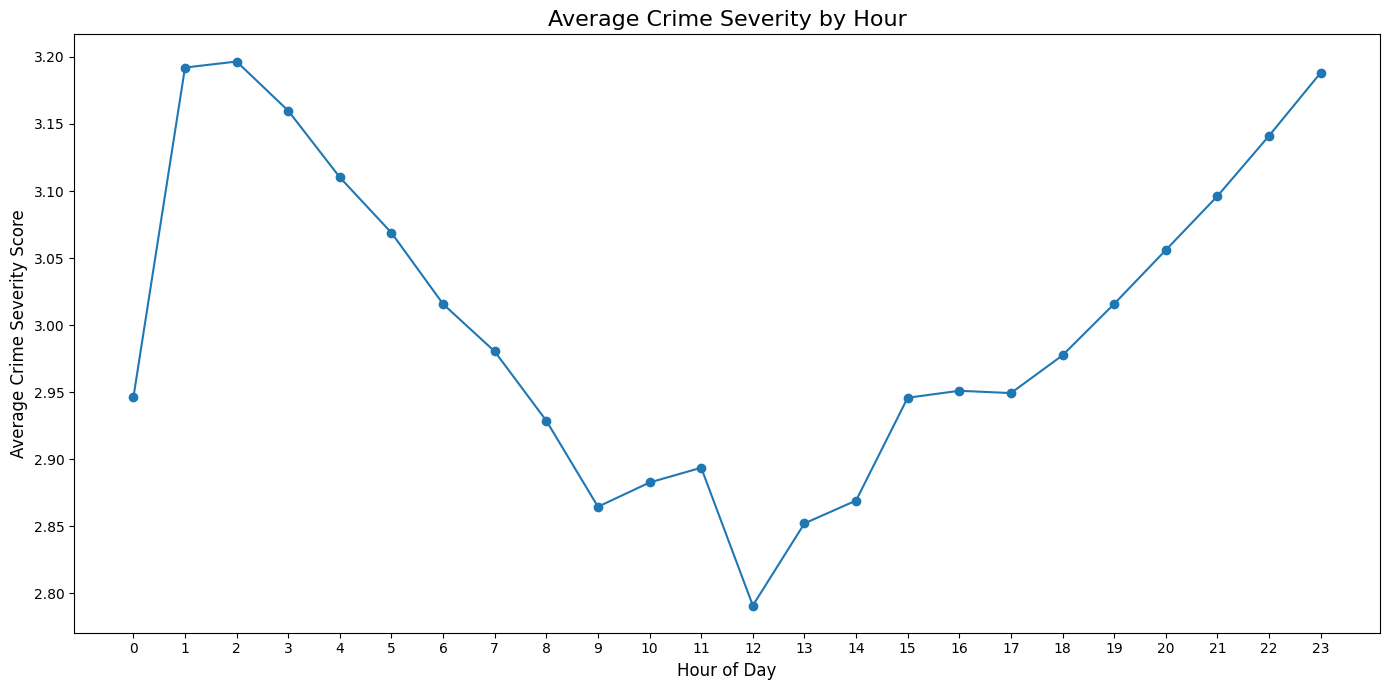

In [58]:
# ==========================================
# EDA 24 - CRIME SEVERITY BY HOUR
# ==========================================

hour_severity = (
    df.groupby("hour")["crime_severity_score"]
    .agg(["mean", "count"])
    .sort_index()
)

print("=" * 60)
print("EDA 24 - CRIME SEVERITY BY HOUR")
print("=" * 60)

print("\nAverage Crime Severity by Hour:")
print(hour_severity.round(2))

# Highest severity hour
highest_hour = hour_severity["mean"].idxmax()

# Lowest severity hour
lowest_hour = hour_severity["mean"].idxmin()

print("\nHighest Average Severity Hour:")
print(
    highest_hour,
    ":00 -",
    round(hour_severity.loc[highest_hour, "mean"], 2)
)

print("\nLowest Average Severity Hour:")
print(
    lowest_hour,
    ":00 -",
    round(hour_severity.loc[lowest_hour, "mean"], 2)
)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(14, 7))

plt.plot(
    hour_severity.index,
    hour_severity["mean"],
    marker="o"
)

plt.title(
    "Average Crime Severity by Hour",
    fontsize=16
)

plt.xlabel(
    "Hour of Day",
    fontsize=12
)

plt.ylabel(
    "Average Crime Severity Score",
    fontsize=12
)

plt.xticks(range(24))

plt.tight_layout()
plt.show()

EDA 25 - CRIME SEVERITY BY SEASON

Average Crime Severity by Season:
        mean   count
season              
Winter  2.96  105715
Spring  2.99  119231
Summer  3.01  149970
Fall    2.98  125084

Highest Average Severity Season:
Summer - 3.01

Lowest Average Severity Season:
Winter - 2.96


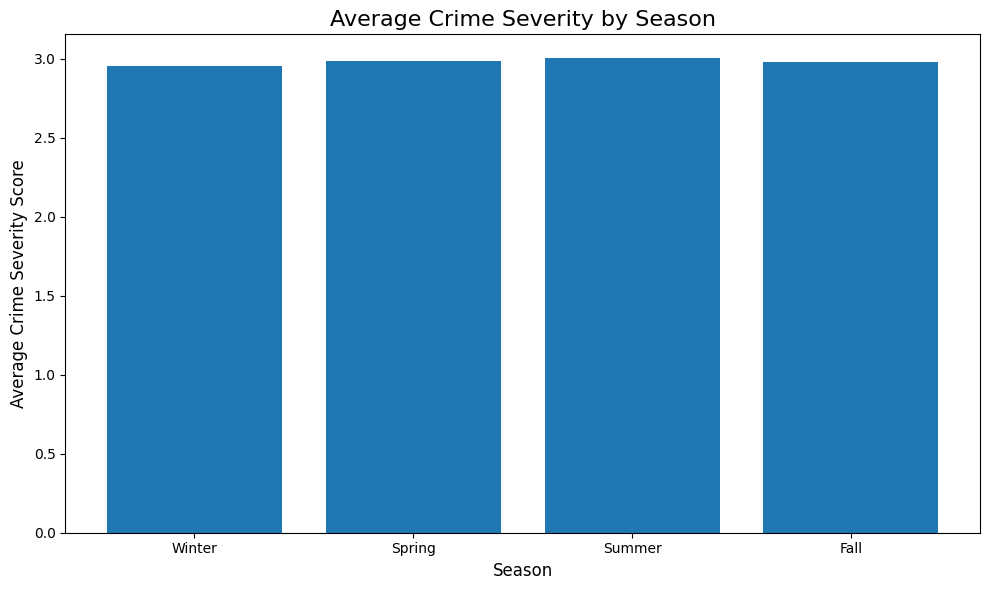

In [59]:
# ==========================================
# EDA 25 - CRIME SEVERITY BY SEASON
# ==========================================

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Fall"
]

season_severity = (
    df.groupby("season", observed=True)["crime_severity_score"]
    .agg(["mean", "count"])
    .reindex(season_order)
)

print("=" * 60)
print("EDA 25 - CRIME SEVERITY BY SEASON")
print("=" * 60)

print("\nAverage Crime Severity by Season:")
print(season_severity.round(2))

# Highest severity season
highest_season = season_severity["mean"].idxmax()

# Lowest severity season
lowest_season = season_severity["mean"].idxmin()

print("\nHighest Average Severity Season:")
print(
    highest_season,
    "-",
    round(season_severity.loc[highest_season, "mean"], 2)
)

print("\nLowest Average Severity Season:")
print(
    lowest_season,
    "-",
    round(season_severity.loc[lowest_season, "mean"], 2)
)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    season_severity.index,
    season_severity["mean"]
)

plt.title(
    "Average Crime Severity by Season",
    fontsize=16
)

plt.xlabel(
    "Season",
    fontsize=12
)

plt.ylabel(
    "Average Crime Severity Score",
    fontsize=12
)

plt.tight_layout()
plt.show()

EDA 26 - ARREST RATE BY DISTRICT

Arrest Rate by District (%):
district
11.0    28.11
10.0    24.20
7.0     19.05
15.0    18.32
5.0     17.98
25.0    17.78
1.0     17.70
9.0     16.23
16.0    14.95
24.0    14.65
17.0    14.32
6.0     14.31
3.0     14.30
8.0     14.24
18.0    13.95
14.0    13.67
22.0    12.52
20.0    12.33
4.0     12.20
2.0     10.79
12.0     9.79
19.0     9.59
Name: arrest, dtype: float64

Highest Arrest Rate District:
11.0 - 28.11 %

Lowest Arrest Rate District:
19.0 - 9.59 %


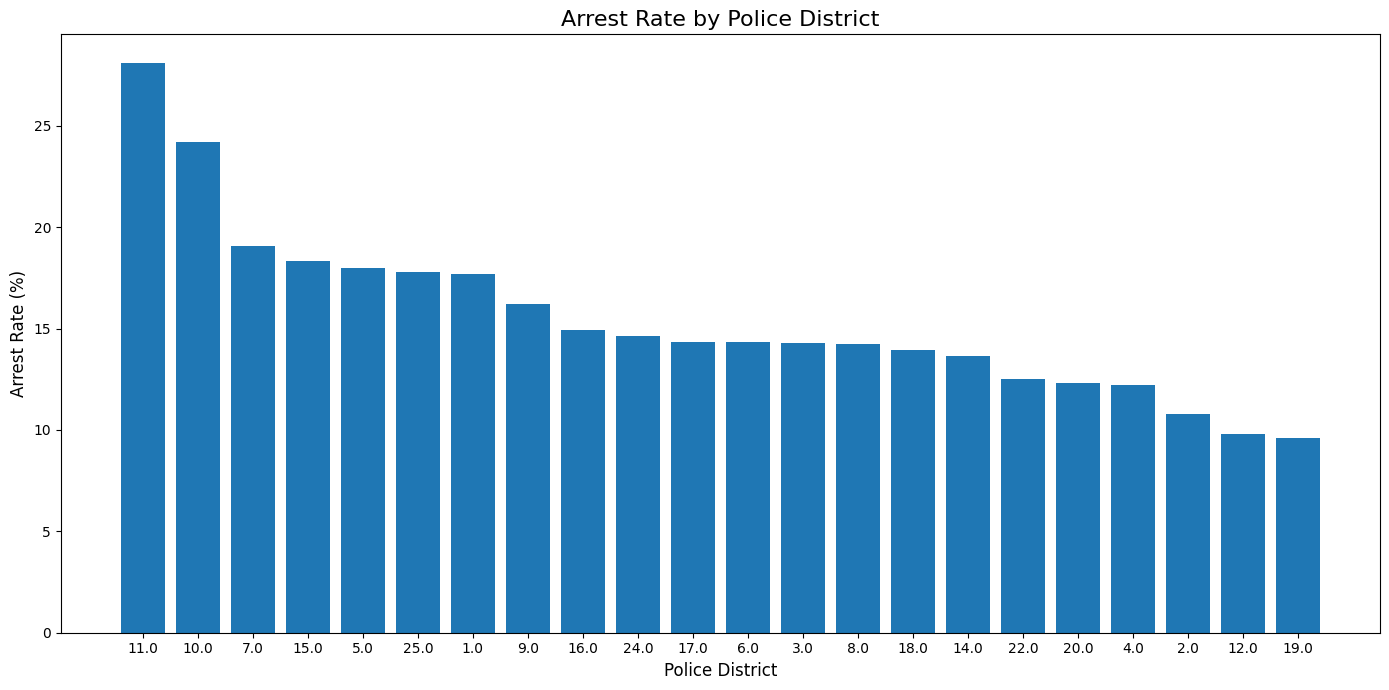

In [60]:
# ==========================================
# EDA 26 - ARREST RATE BY DISTRICT
# ==========================================

district_arrest = (
    df.groupby("district")["arrest"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("=" * 60)
print("EDA 26 - ARREST RATE BY DISTRICT")
print("=" * 60)

print("\nArrest Rate by District (%):")
print(district_arrest.round(2))

print("\nHighest Arrest Rate District:")
print(
    district_arrest.index[0],
    "-",
    round(district_arrest.iloc[0], 2),
    "%"
)

print("\nLowest Arrest Rate District:")
print(
    district_arrest.index[-1],
    "-",
    round(district_arrest.iloc[-1], 2),
    "%"
)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(14, 7))

plt.bar(
    district_arrest.index.astype(str),
    district_arrest.values
)

plt.title(
    "Arrest Rate by Police District",
    fontsize=16
)

plt.xlabel(
    "Police District",
    fontsize=12
)

plt.ylabel(
    "Arrest Rate (%)",
    fontsize=12
)

plt.tight_layout()
plt.show()

EDA 27 - DOMESTIC INCIDENT RATE BY DISTRICT

Domestic Incident Rate by District (%):
district
15.0    30.26
6.0     28.26
7.0     27.80
3.0     27.22
5.0     27.19
4.0     25.62
22.0    23.52
10.0    23.33
11.0    22.05
8.0     21.11
25.0    21.07
2.0     20.30
9.0     19.34
24.0    17.17
16.0    16.22
17.0    14.91
20.0    11.95
12.0    11.17
14.0    10.57
19.0     6.98
1.0      6.63
18.0     6.49
Name: domestic, dtype: float64

Highest Domestic Incident Rate District:
15.0 - 30.26 %

Lowest Domestic Incident Rate District:
18.0 - 6.49 %


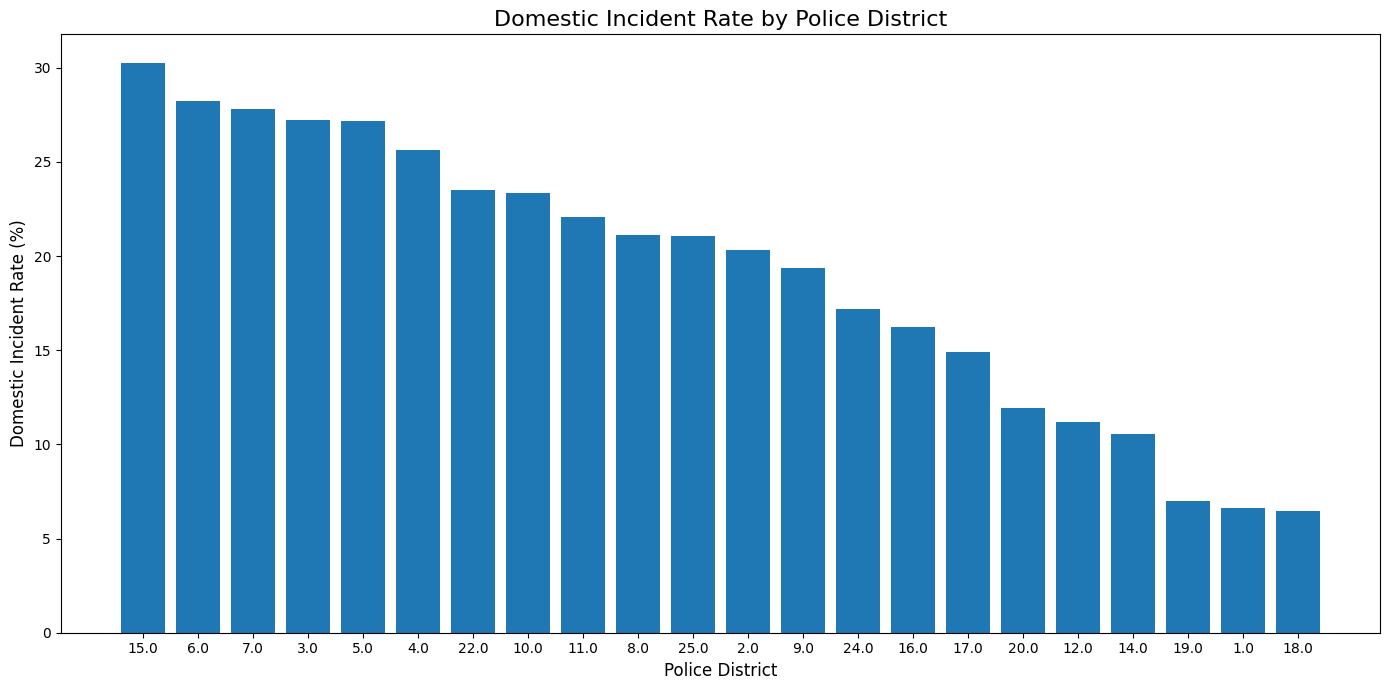

In [61]:
# ==========================================
# EDA 27 - DOMESTIC INCIDENT RATE BY DISTRICT
# ==========================================

district_domestic = (
    df.groupby("district")["domestic"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("=" * 60)
print("EDA 27 - DOMESTIC INCIDENT RATE BY DISTRICT")
print("=" * 60)

print("\nDomestic Incident Rate by District (%):")
print(district_domestic.round(2))

print("\nHighest Domestic Incident Rate District:")
print(
    district_domestic.index[0],
    "-",
    round(district_domestic.iloc[0], 2),
    "%"
)

print("\nLowest Domestic Incident Rate District:")
print(
    district_domestic.index[-1],
    "-",
    round(district_domestic.iloc[-1], 2),
    "%"
)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(14, 7))

plt.bar(
    district_domestic.index.astype(str),
    district_domestic.values
)

plt.title(
    "Domestic Incident Rate by Police District",
    fontsize=16
)

plt.xlabel(
    "Police District",
    fontsize=12
)

plt.ylabel(
    "Domestic Incident Rate (%)",
    fontsize=12
)

plt.tight_layout()
plt.show()

EDA 28 - CRIME VOLUME vs SEVERITY BY DISTRICT

District Crime Volume and Average Severity:
          total_crimes  average_severity
district                                
12.0             32154              2.90
8.0              32135              3.00
1.0              28554              2.77
6.0              28329              3.11
4.0              27327              3.12
18.0             27108              2.71
2.0              27083              2.99
11.0             27012              3.19
3.0              26762              3.15
19.0             26736              2.72
25.0             24927              2.99
9.0              22538              3.06
7.0              21170              3.20
10.0             19888              3.15
5.0              19580              3.08
14.0             18015              2.79
16.0             16927              2.88
15.0             16821              3.20
24.0             15713              2.95
22.0             15535              2.98
17.0   

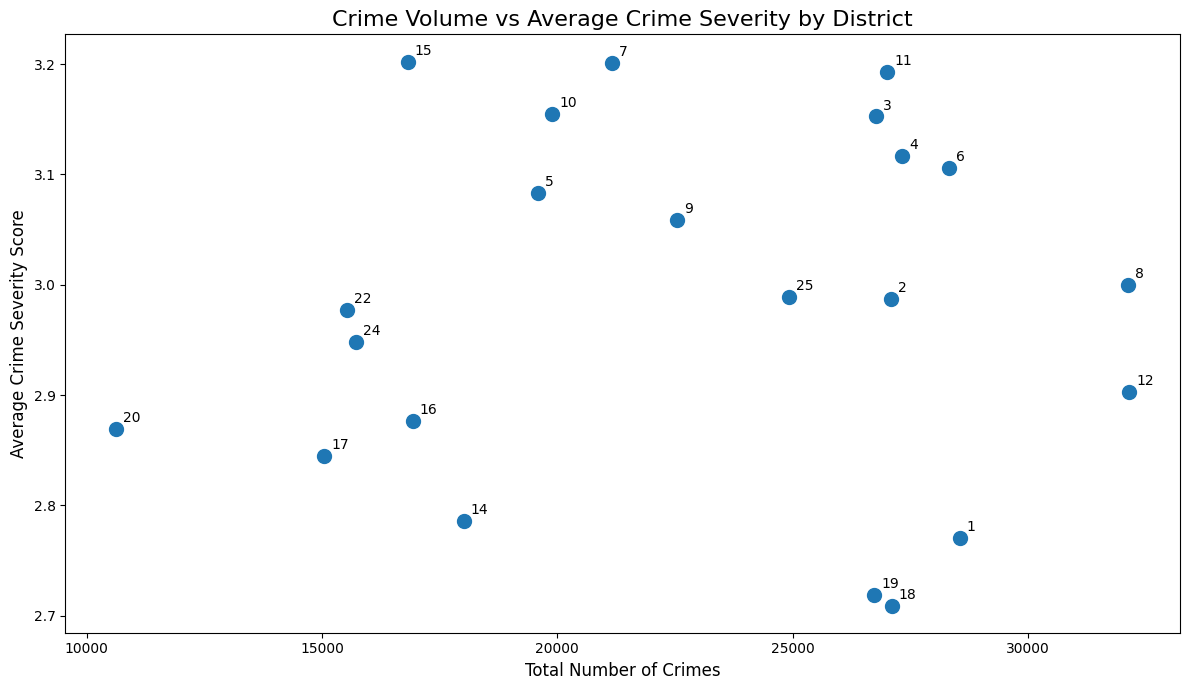

In [62]:
# ==========================================
# EDA 28 - CRIME VOLUME vs SEVERITY BY DISTRICT
# ==========================================

district_analysis = (
    df.groupby("district")
    .agg(
        total_crimes=("id", "count"),
        average_severity=("crime_severity_score", "mean")
    )
    .sort_values("total_crimes", ascending=False)
)

print("=" * 60)
print("EDA 28 - CRIME VOLUME vs SEVERITY BY DISTRICT")
print("=" * 60)

print("\nDistrict Crime Volume and Average Severity:")
print(district_analysis.round(2))

print("\nDistrict with Highest Crime Volume:")
print(
    district_analysis["total_crimes"].idxmax(),
    "-",
    district_analysis["total_crimes"].max(),
    "crimes"
)

print("\nDistrict with Highest Average Severity:")
print(
    district_analysis["average_severity"].idxmax(),
    "-",
    round(district_analysis["average_severity"].max(), 2)
)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(12, 7))

plt.scatter(
    district_analysis["total_crimes"],
    district_analysis["average_severity"],
    s=100
)

# Add district labels
for district, row in district_analysis.iterrows():
    plt.annotate(
        str(int(district)),
        (
            row["total_crimes"],
            row["average_severity"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(
    "Crime Volume vs Average Crime Severity by District",
    fontsize=16
)

plt.xlabel(
    "Total Number of Crimes",
    fontsize=12
)

plt.ylabel(
    "Average Crime Severity Score",
    fontsize=12
)

plt.tight_layout()
plt.show()

EDA 29 - CRIME VOLUME vs ARREST RATE BY DISTRICT

District Crime Volume and Arrest Rate:
          total_crimes  arrest_rate
district                           
12.0             32154         9.79
8.0              32135        14.24
1.0              28554        17.70
6.0              28329        14.31
4.0              27327        12.20
18.0             27108        13.95
2.0              27083        10.79
11.0             27012        28.11
3.0              26762        14.30
19.0             26736         9.59
25.0             24927        17.78
9.0              22538        16.23
7.0              21170        19.05
10.0             19888        24.20
5.0              19580        17.98
14.0             18015        13.67
16.0             16927        14.95
15.0             16821        18.32
24.0             15713        14.65
22.0             15535        12.52
17.0             15046        14.32
20.0             10621        12.33

District with Highest Crime Volume:
12.0 - 321

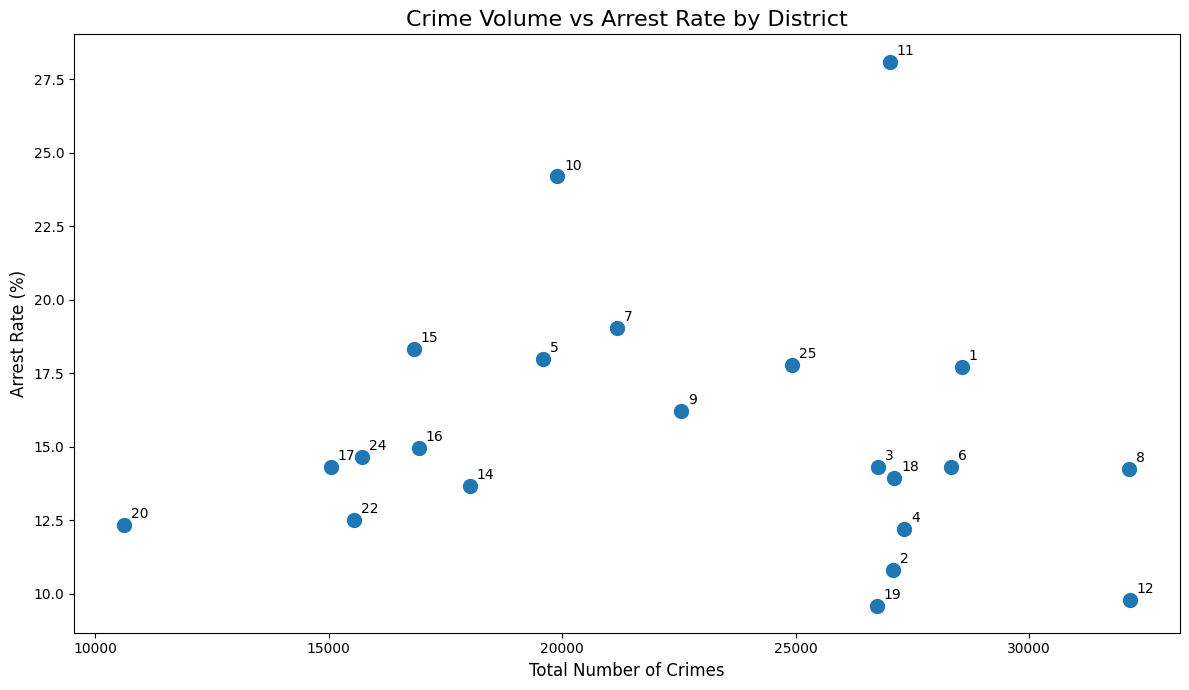

In [63]:
# ==========================================
# EDA 29 - CRIME VOLUME vs ARREST RATE BY DISTRICT
# ==========================================

district_arrest_analysis = (
    df.groupby("district")
    .agg(
        total_crimes=("id", "count"),
        arrest_rate=("arrest", "mean")
    )
)

# Convert arrest rate to percentage
district_arrest_analysis["arrest_rate"] = (
    district_arrest_analysis["arrest_rate"] * 100
)

# Sort by total crimes
district_arrest_analysis = district_arrest_analysis.sort_values(
    "total_crimes",
    ascending=False
)

print("=" * 60)
print("EDA 29 - CRIME VOLUME vs ARREST RATE BY DISTRICT")
print("=" * 60)

print("\nDistrict Crime Volume and Arrest Rate:")
print(district_arrest_analysis.round(2))

print("\nDistrict with Highest Crime Volume:")
print(
    district_arrest_analysis["total_crimes"].idxmax(),
    "-",
    district_arrest_analysis["total_crimes"].max(),
    "crimes"
)

print("\nDistrict with Highest Arrest Rate:")
print(
    district_arrest_analysis["arrest_rate"].idxmax(),
    "-",
    round(
        district_arrest_analysis["arrest_rate"].max(),
        2
    ),
    "%"
)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(12, 7))

plt.scatter(
    district_arrest_analysis["total_crimes"],
    district_arrest_analysis["arrest_rate"],
    s=100
)

# Add district labels
for district, row in district_arrest_analysis.iterrows():
    plt.annotate(
        str(int(district)),
        (row["total_crimes"], row["arrest_rate"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Crime Volume vs Arrest Rate by District", fontsize=16)
plt.xlabel("Total Number of Crimes", fontsize=12)
plt.ylabel("Arrest Rate (%)", fontsize=12)

plt.tight_layout()
plt.show()

EDA 30 - CRIME VOLUME vs DOMESTIC INCIDENT RATE

District Crime Volume and Domestic Incident Rate:
          total_crimes  domestic_rate
district                             
12.0             32154          11.17
8.0              32135          21.11
1.0              28554           6.63
6.0              28329          28.26
4.0              27327          25.62
18.0             27108           6.49
2.0              27083          20.30
11.0             27012          22.05
3.0              26762          27.22
19.0             26736           6.98
25.0             24927          21.07
9.0              22538          19.34
7.0              21170          27.80
10.0             19888          23.33
5.0              19580          27.19
14.0             18015          10.57
16.0             16927          16.22
15.0             16821          30.26
24.0             15713          17.17
22.0             15535          23.52
17.0             15046          14.91
20.0             10621     

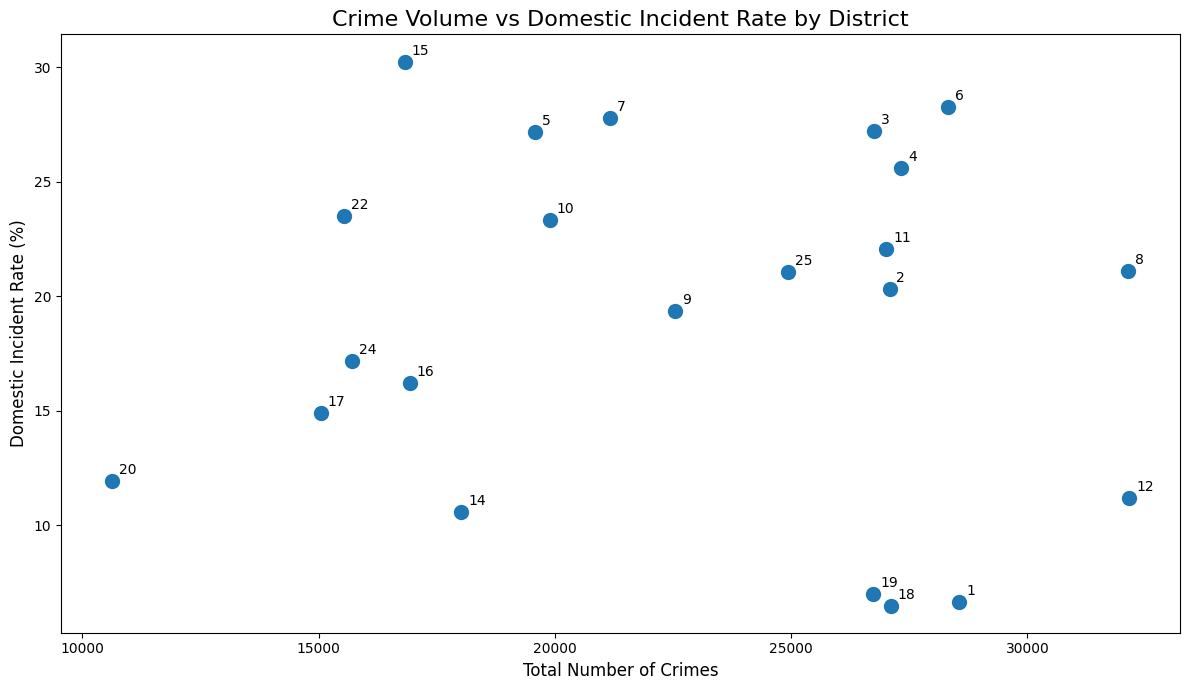

In [64]:
# ==========================================
# EDA 30 - CRIME VOLUME vs DOMESTIC INCIDENT
# RATE BY DISTRICT
# ==========================================

district_domestic_analysis = (
    df.groupby("district")
    .agg(
        total_crimes=("id", "count"),
        domestic_rate=("domestic", "mean")
    )
)

# Convert domestic rate to percentage
district_domestic_analysis["domestic_rate"] = (
    district_domestic_analysis["domestic_rate"] * 100
)

# Sort by crime volume
district_domestic_analysis = district_domestic_analysis.sort_values(
    "total_crimes",
    ascending=False
)

print("=" * 60)
print("EDA 30 - CRIME VOLUME vs DOMESTIC INCIDENT RATE")
print("=" * 60)

print("\nDistrict Crime Volume and Domestic Incident Rate:")
print(district_domestic_analysis.round(2))

print("\nDistrict with Highest Crime Volume:")
print(
    district_domestic_analysis["total_crimes"].idxmax(),
    "-",
    district_domestic_analysis["total_crimes"].max(),
    "crimes"
)

print("\nDistrict with Highest Domestic Incident Rate:")
print(
    district_domestic_analysis["domestic_rate"].idxmax(),
    "-",
    round(
        district_domestic_analysis["domestic_rate"].max(),
        2
    ),
    "%"
)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(12, 7))

plt.scatter(
    district_domestic_analysis["total_crimes"],
    district_domestic_analysis["domestic_rate"],
    s=100
)

# Add district labels
for district, row in district_domestic_analysis.iterrows():
    plt.annotate(
        str(int(district)),
        (
            row["total_crimes"],
            row["domestic_rate"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(
    "Crime Volume vs Domestic Incident Rate by District",
    fontsize=16
)

plt.xlabel("Total Number of Crimes", fontsize=12)
plt.ylabel("Domestic Incident Rate (%)", fontsize=12)

plt.tight_layout()
plt.show()